## 906 LVTestCase — GNN dataset generation (chunked)

Generate chunked OpenDSS snapshot data for DA-GPS training on the **IEEE European LV Test Case** (906 buses / LVTestCase).

This mirrors the 8500 **no-BESS** chunked driver in `withder.ipynb` (calls a thin Python generator per chunk).

### Full vs smoke sizes (same as 8500 chunked)
| Mode | `TOTAL_SCENARIOS` | `N_SAMPLES_PER_SCENARIO` | `SCENARIOS_PER_CHUNK` | chunks |
|---|---|---|---|---|
| Full (`SMOKE_TEST=False`) | 2000 | 40 | 50 | 40 |
| Smoke (`SMOKE_TEST=True`) | 4 | 8 | 2 | 2 |

### Save location (`CHUNK_ROOT`)
- **Colab:** `/content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked`
- **Windows (preferred):** `K:\My Drive\datasets_gnn2\original_906_lvtestcase_chunked`
- Fallback: `D:\datasets\...` or `{repo}\datasets_gnn2\...`

### Differences vs 8500
| | IEEE 8500 unbalanced | 906 LVTestCase |
|---|---|---|
| DER | PV (+ optional BESS) | none (`p_pv_kw=0`) |
| Controls | regs + caps (real meta) | **none** — dummy constant 8500 `reg_*` / `cap_*` meta cols for trainer schema |
| Profiles | 5-min load + irradiance (288 pts) | 1-min per-load shapes (1440 pts) |
| MV aggregation | split-phase → MV `*_mvagg.csv` | **no real mvagg** — writes `gnn_node_features_and_targets_mvagg.csv` as a compat copy |
| Physics loss | optional (8500 Y / device catalog) | keep **off** (no regs/caps / no 8500 catalog) |

### Per-chunk outputs (`run_***/`)
- `gnn_node_index_master.csv` (incl. Laplacian PE)
- `gnn_edges_phase_static.csv`
- `gnn_sample_meta.csv` (incl. dummy cap/reg columns)
- `gnn_node_features_and_targets_mvagg.csv` ← what DA-GPS loads

### After generation
Point the DA-GPS training cell’s `CHUNK_PARENT` at `CHUNK_ROOT` below (same layout as 8500: parent of `run_*` folders). See the short follow-up cell after the generator.


In [ ]:
# ============================================================
# CHUNKED RUN: scenarios x samples/scenario — 906 LVTestCase
# - runs in chunks
# - different seed per chunk
# - different output folder per chunk
# - PE computed from static edges each chunk (node_pe_k > 0, no CSV)
# - writes *_mvagg.csv compat file (identity; no split-phase aggregation)
# - dummy 8500 cap/reg meta columns for existing DA-GPS trainer schema
# ============================================================
import os
import math
import time
from pathlib import Path

# ---------------- user controls ----------------
SMOKE_TEST = False  # True = tiny run to verify paths / OpenDSS; False = full dataset

TOTAL_SCENARIOS = 2000
N_SAMPLES_PER_SCENARIO = 40
SCENARIOS_PER_CHUNK = 50
BASE_SEED = 90620230

SIGMA_LOAD = 0.5
SIGMA_PV = 0.0  # unused (no PV); kept for parity with 8500 cell

# Nominal: 55 x 1 kW @ PF 0.95  →  P≈55 kW, Q≈18.08 kvar
P_LOAD_MEAN_KW = 55.0
Q_LOAD_MEAN_KVAR = 18.077625784837476
P_LOAD_SCALE_RANGE = (0.3, 1.8)
Q_LOAD_SCALE_RANGE = (0.3, 1.8)
P_PV_SCALE_RANGE = (0.0, 0.0)  # no PV on LVTestCase

VMIN_SAFE_PU = 0.55
VMAX_SAFE_PU = 1.45

NODE_PE_K = 8
NODE_PE_SEED = 42
NODE_PE_ZERO_EIG_TOL = 1e-8

RETURN_NODE_DF = False
WRITE_MVAGG_COMPAT = True
DELETE_RAW_NODE_CSV_AFTER_MVAGG = True  # training only needs *_mvagg.csv

if SMOKE_TEST:
    TOTAL_SCENARIOS = 4
    N_SAMPLES_PER_SCENARIO = 8
    SCENARIOS_PER_CHUNK = 2
    print("SMOKE_TEST=True → TOTAL_SCENARIOS=4, N_SAMPLES_PER_SCENARIO=8, SCENARIOS_PER_CHUNK=2")

# Colab / Windows / local defaults — edit CHUNK_ROOT to your Drive / disk
CANDIDATES = [
    r"C:\Users\alita\OneDrive\Desktop\GNN2",
    "/content/GNN-Sandia",
    "/content/GNN2",
    os.getcwd(),
]

_REPO = None
for root in CANDIDATES:
    if os.path.isdir(root) and os.path.isfile(os.path.join(root, "run_original_style_dataset_906_lvtestcase.py")):
        _REPO = os.path.abspath(root)
        break
if _REPO is None:
    raise FileNotFoundError("Could not locate repo root containing run_original_style_dataset_906_lvtestcase.py")

# Do NOT use Path("/content/...").exists() — on Windows that is drive-root-relative
# (e.g. C:\content\...) and stays True forever after a mistaken mkdir.
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

_K_GNN2 = Path(r"K:\My Drive\datasets_gnn2")
_K_MYDRIVE = Path(r"K:\My Drive")

if IN_COLAB:
    CHUNK_ROOT = Path("/content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked")
elif _K_GNN2.exists() or _K_MYDRIVE.exists():
    CHUNK_ROOT = _K_GNN2 / "original_906_lvtestcase_chunked"
elif Path(r"D:\datasets").exists():
    CHUNK_ROOT = Path(r"D:\datasets\original_906_lvtestcase_chunked")
else:
    CHUNK_ROOT = Path(_REPO) / "datasets_gnn2" / "original_906_lvtestcase_chunked"

CHUNK_ROOT.mkdir(parents=True, exist_ok=True)
print("CHUNK_ROOT:", CHUNK_ROOT)

script_path = os.path.join(_REPO, "run_original_style_dataset_906_lvtestcase.py")
os.chdir(_REPO)
print("CWD:", os.getcwd())
print("SCRIPT:", script_path)

ns = {"__name__": "run_original_style_dataset_906_lvtestcase", "__file__": script_path}
exec(open(script_path, encoding="utf-8").read(), ns)

# ---------------- preflight ----------------
model_dir = ns["MODEL_DIR"]
master_dss = ns["MASTER_DSS"]
print("MODEL_DIR:", model_dir)
print("MASTER_DSS exists:", master_dss.is_file())
if not master_dss.is_file():
    raise FileNotFoundError(f"Missing LVTestCase Master.dss: {master_dss}")

n_chunks = math.ceil(TOTAL_SCENARIOS / SCENARIOS_PER_CHUNK)
print(f"\nTotal chunks: {n_chunks} | SMOKE_TEST={SMOKE_TEST}")
print(f"P_LOAD_MEAN_KW={P_LOAD_MEAN_KW}  Q_LOAD_MEAN_KVAR={Q_LOAD_MEAN_KVAR}")

for chunk_idx in range(n_chunks):
    s0 = chunk_idx * SCENARIOS_PER_CHUNK
    n_this = min(SCENARIOS_PER_CHUNK, TOTAL_SCENARIOS - s0)
    chunk_seed = int(BASE_SEED + 100003 * (chunk_idx + 1))
    out_dir = CHUNK_ROOT / f"run_{chunk_idx+1:03d}_scen_{s0:04d}_{s0+n_this-1:04d}_seed_{chunk_seed}"
    out_dir.mkdir(parents=True, exist_ok=True)

    ns["OUT_DIR"] = out_dir
    ns["EDGE_CSV"] = out_dir / "gnn_edges_phase_static.csv"
    ns["NODE_CSV"] = out_dir / "gnn_node_features_and_targets.csv"
    ns["SAMPLE_CSV"] = out_dir / "gnn_sample_meta.csv"
    ns["NODE_INDEX_CSV"] = out_dir / "gnn_node_index_master.csv"
    ns["MVAGG_CSV"] = out_dir / "gnn_node_features_and_targets_mvagg.csv"

    print(f"\n=== Chunk {chunk_idx+1}/{n_chunks} ===")
    print(f"Scenarios in chunk: {n_this}")
    print(f"Seed: {chunk_seed}")
    print(f"OUT_DIR: {out_dir}")

    gen_kw = dict(
        n_scenarios=int(n_this),
        k_snapshots_per_scenario_total=int(N_SAMPLES_PER_SCENARIO),
        bins_by_profile={"load": 3, "pv": 3, "net": 3},
        include_anchors=True,
        master_seed=int(chunk_seed),
        sigma_load=float(SIGMA_LOAD),
        sigma_pv=float(SIGMA_PV),
        p_load_mean_kw=float(P_LOAD_MEAN_KW),
        q_load_mean_kvar=float(Q_LOAD_MEAN_KVAR),
        p_load_scale_range=tuple(P_LOAD_SCALE_RANGE),
        q_load_scale_range=tuple(Q_LOAD_SCALE_RANGE),
        p_pv_scale_range=tuple(P_PV_SCALE_RANGE),
        vmin_safe_pu=float(VMIN_SAFE_PU),
        vmax_safe_pu=float(VMAX_SAFE_PU),
        include_source_in_safe_band=False,
        return_node_df=bool(RETURN_NODE_DF),
        node_pe_k=int(NODE_PE_K),
        node_pe_seed=int(NODE_PE_SEED),
        node_pe_zero_eig_tol=float(NODE_PE_ZERO_EIG_TOL),
        write_mvagg_compat=bool(WRITE_MVAGG_COMPAT),
        delete_raw_node_csv_after_mvagg=bool(DELETE_RAW_NODE_CSV_AFTER_MVAGG),
    )

    t0 = time.time()
    df_sample, df_node = ns["generate_original_style_dataset_906_lvtestcase"](**gen_kw)

    dt = time.time() - t0
    n_kept = int(df_sample["sample_id"].nunique()) if len(df_sample) else 0
    print(f"Chunk done in {dt/60:.1f} min | kept samples: {n_kept} | rows sample_meta: {len(df_sample)}")
    print("Saved:")
    print(" -", ns["NODE_INDEX_CSV"])
    print(" -", ns["EDGE_CSV"])
    print(" -", ns["SAMPLE_CSV"])
    if not DELETE_RAW_NODE_CSV_AFTER_MVAGG:
        print(" -", ns["NODE_CSV"])
    print(" -", ns["MVAGG_CSV"])

print("\nAll chunks finished.")
print("Next: set DA-GPS CHUNK_PARENT to:", CHUNK_ROOT)


## DA-GPS training on 906 LVTestCase (chunked)

Train the existing multitask DA-GPS model on the **already-generated** 906 chunked dataset. **Do not regenerate** data for training — point at:

- Local: `K:\My Drive\datasets_gnn2\original_906_lvtestcase_chunked`
- Colab: `/content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked`

### System / latent tokens (this trainer)

`--n_system_tokens` allocates learnable **global tokens** after the fixed cap-bank and regulator tokens. With `--aux_meta_cols col0,col1,...`, column `i` supervises system-token slot `i` (global index `n_cap + n_reg + i`) via normalized MSE (`--lambda_pv`). Remaining system tokens (if any) stay unsupervised latents. For 906 we use **2** tokens tied to **substation upstream P and Q**: `P_grid_upstream_post_kw,Q_grid_upstream_post_kvar`.

### 906 vs 8500 training differences

| Setting | 8500 (typical) | 906 (this cell) |
|--------|----------------|-----------------|
| Dataset | `original_8500_..._2000_40` | `original_906_lvtestcase_chunked` |
| Meta aux | PV + losses | Substation P/Q only |
| `n_system_tokens` | 10 | 2 |
| Cap / reg loss | `lambda_cap/reg > 0` | **0** (dummy columns only) |
| PV aux weight | `lambda_pv > 0` on PV cols | `lambda_pv` on grid P/Q (no `pv_pv2_*`) |
| Physics | optional PF catalogs | **always off** (`PHYSICS_WEIGHT=0`) |
| Loss meta units | as stored | `--meta_loss_scale 0.001` if/when `P_loss_*` / `Q_loss_*` are ingested |

### Loss scale without regenerating CSVs

906 meta currently stores `P_loss_total_post_kw` / `Q_loss_total_post_kvar` ~**1000x** too large. The trainer flag `--meta_loss_scale 0.001` multiplies those two columns whenever they are loaded into aux/cache targets (default `1.0` keeps 8500 unchanged). This cell passes `0.001` for correctness if losses are ever added to `--aux_meta_cols`; substation P/Q tokens are **not** scaled.

### Smoke vs full

- `SMOKE_TEST=True`: prefer the first few **full-size** `run_*` chunks (scen span ≥ 50 in the folder name); if none exist, fall back to any `run_*`. Fewer epochs (fast check).
- `SMOKE_TEST=False`: **all full-size** chunks only (scen span ≥ 50). Smoke folders like `run_001_scen_0000_0001_...` (span=2) are **auto-skipped** — leave them on disk; no need to delete.

Caches use **906-specific** names (`da_gps_chunked_906_...`) so they never collide with 8500 caches. Runs go under `.../datasets_gnn2/runs`.


In [ ]:
# --- DA-GPS training on 906 LVTestCase (long-running; Colab GPU or local CUDA) ---
import os
import sys
import re
import subprocess
import datetime
import warnings
from pathlib import Path

DRIVE_ROOT = Path("/content/drive")
MYDRIVE_DATA = DRIVE_ROOT / "MyDrive/datasets_gnn2"
COLAB_CHUNK_DEFAULT = MYDRIVE_DATA / "original_906_lvtestcase_chunked"
WIN_CHUNK_DEFAULT = Path(r"K:\My Drive\datasets_gnn2\original_906_lvtestcase_chunked")
WIN_RUNS_DEFAULT = Path(r"K:\My Drive\datasets_gnn2\runs")
WIN_CACHE_PARENT = Path(r"K:\My Drive\datasets_gnn2\cache")


def _is_windows_drive_path(path) -> bool:
    s = str(path).strip().replace("/", "\\")
    return len(s) >= 2 and s[1] == ":" and s[0].isalpha()


def _on_colab() -> bool:
    try:
        import google.colab  # noqa: F401
        return True
    except ImportError:
        return False


def _drive_mounted() -> bool:
    return DRIVE_ROOT.is_dir() and (DRIVE_ROOT / "MyDrive").is_dir()


def _resolve_data_path(path: Path, *, label: str, colab_fallback: Path | None = None) -> Path:
    """Resolve a data path; never join Windows drive letters with cwd on Linux."""
    raw = str(path)
    if _is_windows_drive_path(raw):
        if _on_colab() and colab_fallback is not None:
            warnings.warn(
                f"{label}={raw!r} is a Windows path on Linux/Colab; using {colab_fallback} instead.",
                UserWarning,
                stacklevel=2,
            )
            return colab_fallback.expanduser().resolve()
        if _on_colab():
            raise ValueError(
                f"{label}={raw!r} is a Windows absolute path and invalid on Colab. "
                f"Mount Drive and use e.g. {COLAB_CHUNK_DEFAULT}"
            )
        return Path(raw).expanduser().resolve()
    p = Path(path).expanduser()
    if p.is_absolute():
        return p.resolve()
    return (Path.cwd() / p).resolve()


def _find_node_pe_csv(chunk_parent: Path) -> Path:
    hits = sorted(chunk_parent.glob("run_*/gnn_node_index_master.csv"))
    if not hits:
        raise FileNotFoundError(
            f"No run_*/gnn_node_index_master.csv under {chunk_parent}"
        )
    return hits[0]


def _sorted_run_chunk_dirs(chunk_parent: Path) -> list[Path]:
    return sorted(
        (p for p in chunk_parent.iterdir() if p.is_dir() and p.name.startswith("run_")),
        key=lambda p: p.name,
    )


_FULL_CHUNK_MIN_SCEN = 50  # full: scen_0000_0049 => 50; smoke: scen_0000_0001 => 2


def _parse_run_scen_span(name: str) -> int | None:
    """Return (end - start + 1) from run_*_scen_{start}_{end}_seed_*, else None."""
    m = re.search(r"_scen_(\d+)_(\d+)(?:_|$)", name)
    if not m:
        return None
    start, end = int(m.group(1)), int(m.group(2))
    if end < start:
        return None
    return end - start + 1


def _classify_run_chunks(chunk_parent: Path, *, min_full_span: int = _FULL_CHUNK_MIN_SCEN):
    """Split run_* dirs into full vs other/smoke by scen span in the folder name."""
    all_runs = _sorted_run_chunk_dirs(chunk_parent)
    full, other = [], []
    for p in all_runs:
        span = _parse_run_scen_span(p.name)
        if span is not None and span >= min_full_span:
            full.append(p)
        else:
            other.append((p, span))
    return all_runs, full, other


def _select_training_chunk_glob(
    chunk_parent: Path,
    *,
    smoke: bool,
    smoke_count: int,
    min_full_span: int = _FULL_CHUNK_MIN_SCEN,
) -> str:
    """Build --chunk_subdir_glob with full vs smoke awareness.

    Full training (smoke=False): keep only folders whose scen span >= min_full_span
    (typically 50). Smoke folders (span=2) are skipped without deleting them.

    Smoke training (smoke=True): prefer the first `smoke_count` *full-size* chunks
    when available; otherwise fall back to the first `smoke_count` any run_*.
    """
    all_runs, full, other = _classify_run_chunks(chunk_parent, min_full_span=min_full_span)
    if not all_runs:
        raise FileNotFoundError(f"No run_* under {chunk_parent}")

    print(
        f"Chunk selection (SMOKE_TEST={smoke}, min_full_scen_span={min_full_span}): "
        f"{len(all_runs)} run_* found; {len(full)} full-size, {len(other)} other/smoke"
    )

    if smoke:
        pool = full if full else all_runs
        source = "full-size" if full else "any run_* (no full-size chunks found)"
        if len(pool) < smoke_count:
            raise ValueError(
                f"SMOKE_CHUNK_COUNT={smoke_count} but only {len(pool)} {source} "
                f"under {chunk_parent}"
            )
        kept = pool[:smoke_count]
        kept_names = {p.name for p in kept}
        print(f"  smoke: taking first {smoke_count} from {source}")
        for p in all_runs:
            span = _parse_run_scen_span(p.name)
            span_s = f"span={span}" if span is not None else "unparseable span"
            if p.name in kept_names:
                print(f"  KEEP  {p.name} ({span_s})")
            elif full and p not in full:
                print(f"  SKIP  {p.name} ({span_s}; smoke prefers full-size chunks)")
            else:
                print(f"  SKIP  {p.name} ({span_s}; beyond first {smoke_count})")
        return ",".join(p.name for p in kept)

    if not full:
        raise RuntimeError(
            f"SMOKE_TEST=False but no full-size chunks (scen span >= {min_full_span}) "
            f"under {chunk_parent}. Found {len(all_runs)} run_* folder(s)."
        )
    for p, span in other:
        span_s = f"span={span}" if span is not None else "unparseable span"
        print(
            f"  SKIP  {p.name} ({span_s}; need span>={min_full_span} for full training)"
        )
    for p in full:
        span = _parse_run_scen_span(p.name)
        print(f"  KEEP  {p.name} (span={span}; full)")
    return ",".join(p.name for p in full)


def _chunks_from_subdir_glob(chunk_parent: Path, glob_pat: str) -> list[Path]:
    import fnmatch

    glob_pat = str(glob_pat).strip()
    if "," in glob_pat:
        allowed = {s.strip() for s in glob_pat.split(",") if s.strip()}
        chunks = sorted(
            (p for p in chunk_parent.iterdir() if p.is_dir() and p.name in allowed),
            key=lambda p: p.name,
        )
        missing = allowed - {p.name for p in chunks}
        if missing:
            raise FileNotFoundError(f"Missing smoke chunk folders: {sorted(missing)}")
        return chunks
    return sorted(
        (p for p in chunk_parent.iterdir() if p.is_dir() and fnmatch.fnmatch(p.name, glob_pat)),
        key=lambda p: p.name,
    )


def _write_smoke_compare_manifest(
    runs_parent: Path,
    *,
    out_dir: Path,
    physics_weight: float,
    chunk_glob: str,
    n_chunks: int,
    epochs: int,
    seed: int,
) -> None:
    import json as _json

    path = runs_parent / "_smoke_compare_manifest_906.json"
    manifest = {}
    if path.is_file():
        manifest = _json.loads(path.read_text(encoding="utf-8"))
    key = "physics" if physics_weight > 0 else "baseline"
    manifest[key] = {
        "run_dir": str(out_dir.resolve()),
        "physics_weight": physics_weight,
        "chunk_glob": chunk_glob,
        "n_chunks": n_chunks,
        "epochs": epochs,
        "seed": seed,
        "feeder": "906_lvtestcase",
    }
    path.write_text(_json.dumps(manifest, indent=2), encoding="utf-8")
    print(f"Smoke compare manifest ({key}) -> {path}")


# Colab: mount Drive when chunks/caches live under MyDrive
if _on_colab() and not _drive_mounted():
    from google.colab import drive
    drive.mount("/content/drive")

# --- smoke / full-run toggles ---
SMOKE_TEST = True
SMOKE_CHUNK_COUNT = 3  # first N full-size run_* when available; 3-5 = fast multi-chunk
SMOKE_EPOCHS = 15
SMOKE_PATIENCE = 5
SMOKE_SEED = 42
_DA_CACHE_NAME = "da_gps_chunked_906_smoke_gine" if SMOKE_TEST else "da_gps_chunked_906_full_gine"
_GNN_CACHE_NAME = "gnn_only_chunked_906_full_gine"

# --- paths: auto-detect Colab + Drive; prefer K: on Windows ---
_env_repo = os.environ.get("GNN2_REPO_ROOT", "").strip()
REPO = Path(_env_repo).expanduser().resolve() if _env_repo else Path.cwd().resolve()
if not (REPO / "train_da_gps_multitask_complex_voltage_gine.py").is_file():
    raise FileNotFoundError(f"Repo root missing trainer script: {REPO}")

if _on_colab():
    if not _drive_mounted():
        raise RuntimeError(
            "Colab requires Google Drive mounted. Re-run this cell and approve Drive access, "
            "or: from google.colab import drive; drive.mount('/content/drive')"
        )
    CHUNK_PARENT = COLAB_CHUNK_DEFAULT
    DA_CACHE_ROOT = MYDRIVE_DATA / f"cache/{_DA_CACHE_NAME}"
    GNN_CACHE_ROOT = MYDRIVE_DATA / f"cache/{_GNN_CACHE_NAME}"
    RUNS_PARENT = MYDRIVE_DATA / "runs"
elif os.name == "nt":
    CHUNK_PARENT = WIN_CHUNK_DEFAULT
    DA_CACHE_ROOT = WIN_CACHE_PARENT / _DA_CACHE_NAME
    GNN_CACHE_ROOT = WIN_CACHE_PARENT / _GNN_CACHE_NAME
    RUNS_PARENT = WIN_RUNS_DEFAULT
else:
    CHUNK_PARENT = REPO / "datasets_gnn2_from pc/original_906_lvtestcase_chunked"
    DA_CACHE_ROOT = REPO / f"datasets_gnn2_from pc/cache/{_DA_CACHE_NAME}"
    GNN_CACHE_ROOT = REPO / f"datasets_gnn2_from pc/cache/{_GNN_CACHE_NAME}"
    RUNS_PARENT = REPO / "datasets_gnn2_from pc/runs"

NODE_PE_CSV = None  # auto: first run_*/gnn_node_index_master.csv under CHUNK_PARENT

# Optional overrides (use POSIX paths on Colab, not K:\...):
# CHUNK_PARENT = Path("/content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked")
# NODE_PE_CSV = CHUNK_PARENT / "run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv"

# --- lighter architecture ---
LIGHTER_HIDDEN = 64
LIGHTER_LAYERS = 2
LIGHTER_HEADS = 2
LIGHTER_NODE_EMB_DIM = 2

PHYSICS_WEIGHT = 0.0  # always off for 906 (no 8500 PF catalogs)

# Substation upstream P/Q only (no PV aux, no loss tokens)
META_AUX_COLS = "P_grid_upstream_post_kw,Q_grid_upstream_post_kvar"
N_SYSTEM_TOKENS = 2
META_LOSS_SCALE = 0.001  # fix buggy stored P/Q loss units if those cols are ingested
LAMBDA_PV = 0.1  # weight for meta-aux MSE on the 2 system tokens
LAMBDA_CAP = 0.0
LAMBDA_REG = 0.0

NUM_WORKERS = 0 if os.name == "nt" else 4

os.chdir(REPO)
sys.path.insert(0, str(REPO))
os.environ["PYTHONUNBUFFERED"] = "1"
os.environ.setdefault("GNN2_REPO_ROOT", str(REPO))

_colab_fb = COLAB_CHUNK_DEFAULT if _on_colab() else None
chunk_parent = _resolve_data_path(CHUNK_PARENT, label="CHUNK_PARENT", colab_fallback=_colab_fb)
if SMOKE_TEST:
    EPOCHS = SMOKE_EPOCHS
    PATIENCE = SMOKE_PATIENCE
else:
    EPOCHS = 200
    PATIENCE = 30
# Full: only scen-span >= 50 folders. Smoke: prefer first N full-size, else any run_*.
CHUNK_GLOB = _select_training_chunk_glob(
    chunk_parent, smoke=SMOKE_TEST, smoke_count=SMOKE_CHUNK_COUNT
)
da_cache_root = _resolve_data_path(
    DA_CACHE_ROOT,
    label="DA_CACHE_ROOT",
    colab_fallback=MYDRIVE_DATA / f"cache/{_DA_CACHE_NAME}" if _on_colab() else None,
)
gnn_cache_root = _resolve_data_path(
    GNN_CACHE_ROOT,
    label="GNN_CACHE_ROOT",
    colab_fallback=MYDRIVE_DATA / f"cache/{_GNN_CACHE_NAME}" if _on_colab() else None,
)
runs_parent = _resolve_data_path(
    RUNS_PARENT,
    label="RUNS_PARENT",
    colab_fallback=MYDRIVE_DATA / "runs" if _on_colab() else None,
)

print("=== Preflight (906 DA-GPS) ===")
print(f"REPO:           {REPO}")
print(f"SMOKE_TEST:     {SMOKE_TEST}")
print(f"SMOKE_CHUNK_COUNT: {SMOKE_CHUNK_COUNT}")
print(f"CHUNK_GLOB:     {CHUNK_GLOB}")
print(f"EPOCHS:         {EPOCHS}")
print(f"PATIENCE:       {PATIENCE}")
print(f"CHUNK_PARENT:   {chunk_parent}")
print(f"META_AUX_COLS:  {META_AUX_COLS}")
print(f"N_SYSTEM_TOKENS:{N_SYSTEM_TOKENS}")
print(f"META_LOSS_SCALE:{META_LOSS_SCALE}")
print(f"lambda_cap/reg/pv: {LAMBDA_CAP}/{LAMBDA_REG}/{LAMBDA_PV}")
print(f"PHYSICS_WEIGHT: {PHYSICS_WEIGHT}")
if not chunk_parent.is_dir():
    raise FileNotFoundError(f"CHUNK_PARENT not found: {chunk_parent}")

run_preview = sorted(
    p.name for p in chunk_parent.iterdir() if p.is_dir() and p.name.startswith("run_")
)[:5]
print(f"run_* preview:  {run_preview}")

if NODE_PE_CSV is None:
    node_pe = _find_node_pe_csv(chunk_parent)
else:
    node_pe = _resolve_data_path(NODE_PE_CSV, label="NODE_PE_CSV", colab_fallback=None)
    if not node_pe.is_file():
        warnings.warn(
            f"NODE_PE_CSV not found at {node_pe}; auto-discovering under CHUNK_PARENT.",
            UserWarning,
            stacklevel=2,
        )
        node_pe = _find_node_pe_csv(chunk_parent)

print(f"NODE_PE_CSV:    {node_pe}")
print(f"DA_CACHE_ROOT:  {da_cache_root}")
print(f"GNN_CACHE_ROOT: {gnn_cache_root}")
print(f"RUNS_PARENT:    {runs_parent}")
print("PF_DATA_ROOT:   (skipped — PHYSICS_WEIGHT=0)")
print("=================")

da_cache_root.mkdir(parents=True, exist_ok=True)
gnn_cache_root.mkdir(parents=True, exist_ok=True)
runs_parent.mkdir(parents=True, exist_ok=True)

chunks = _chunks_from_subdir_glob(chunk_parent, CHUNK_GLOB)
if not chunks:
    raise RuntimeError(f"No folders for CHUNK_GLOB={CHUNK_GLOB!r} under {chunk_parent}")

for p in chunks:
    for name in (
        "gnn_node_features_and_targets_mvagg.csv",
        "gnn_edges_phase_static.csv",
        "gnn_sample_meta.csv",
    ):
        if not (p / name).is_file():
            raise FileNotFoundError(f"Missing {name} in {p.name}")

print(f"Found {len(chunks)} chunk(s) for CHUNK_GLOB under {chunk_parent}")

tag = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
out_dir = runs_parent / (
    f"da_gps_906_l{LIGHTER_LAYERS}_h{LIGHTER_HIDDEN}_gine_gridPQ"
    f"{'_smoke' if SMOKE_TEST else ''}_{tag}"
)
out_dir.mkdir(parents=True, exist_ok=True)

_early_stop = "total"

cmd = [
    sys.executable, "-u", "train_da_gps_multitask_complex_voltage_gine.py",
    "--chunk_parent", str(chunk_parent),
    "--chunk_subdir_glob", CHUNK_GLOB,
    "--nodes_csv", "gnn_node_features_and_targets_mvagg.csv",
    "--edge_catalog_csv", "gnn_edges_phase_static.csv",
    "--meta_csv", "gnn_sample_meta.csv",
    "--node_feature_cols", "p_load_kw,q_load_kvar,p_pv_kw",
    "--exclude_bess_features",
    "--node_pe_csv", str(node_pe),
    "--node_pe_cols", "auto",
    "--n_system_tokens", str(N_SYSTEM_TOKENS),
    "--aux_meta_cols", META_AUX_COLS,
    "--meta_loss_scale", str(META_LOSS_SCALE),
    "--lambda_pv", str(LAMBDA_PV),
    "--out_dir", str(out_dir),
    "--cache_dir", str(da_cache_root),
    "--bootstrap_gnn_cache_dir", str(gnn_cache_root),
    "--epochs", str(EPOCHS),
    "--batch_size", "64",
    "--hidden", str(LIGHTER_HIDDEN),
    "--layers", str(LIGHTER_LAYERS),
    "--heads", str(LIGHTER_HEADS),
    "--node_emb_dim", str(LIGHTER_NODE_EMB_DIM),
    "--edge_emb_dim", "0",
    "--lr", "5e-4",
    "--weight_decay", "1e-5",
    "--lambda_cap", str(LAMBDA_CAP),
    "--lambda_reg", str(LAMBDA_REG),
    "--reg_loss", "mse",
    "--patience", str(PATIENCE),
    "--seed", str(SMOKE_SEED),
    "--train_frac", "0.80",
    "--val_frac", "0.10",
    "--sample_frac", "1.0",
    "--num_workers", str(NUM_WORKERS),
    "--log_every", "10",
    "--checkpoint_every", "10",
    "--early_stop_on", _early_stop,
    "--dropout", "0.1",
]

# PHYSICS_WEIGHT must stay 0 for 906 — no PF flags added.

print(f"PHYSICS_WEIGHT={PHYSICS_WEIGHT} (baseline; no 8500 physics)")
print(f"early_stop_on={_early_stop}")
print("\nRunning:\n ", " ".join(cmd), "\n", flush=True)

with subprocess.Popen(
    cmd,
    cwd=str(REPO),
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    bufsize=1,
    text=True,
) as proc:
    assert proc.stdout is not None
    for line in proc.stdout:
        print(line, end="")
    rc = proc.wait()

if rc != 0:
    raise subprocess.CalledProcessError(rc, cmd)

print("\nTraining completed.")
print("Run dir:", out_dir.resolve())
print("Checkpoint (best):", (out_dir / "da_gps_multitask_best.pt").resolve())
print("Checkpoint (last):", (out_dir / "training_last.pt").resolve())
print("Report:", (out_dir / "da_gps_report.json").resolve())
_write_smoke_compare_manifest(
    runs_parent,
    out_dir=out_dir,
    physics_weight=PHYSICS_WEIGHT,
    chunk_glob=CHUNK_GLOB,
    n_chunks=len(chunks),
    epochs=EPOCHS,
    seed=SMOKE_SEED if SMOKE_TEST else 42,
)


Chunk selection (SMOKE_TEST=False, min_full_scen_span=50): 42 run_* found; 40 full-size, 2 other/smoke
  SKIP  run_001_scen_0000_0001_seed_90720233 (span=2; need span>=50 for full training)
  SKIP  run_002_scen_0002_0003_seed_90820236 (span=2; need span>=50 for full training)
  KEEP  run_001_scen_0000_0049_seed_90720233 (span=50; full)
  KEEP  run_002_scen_0050_0099_seed_90820236 (span=50; full)
  KEEP  run_003_scen_0100_0149_seed_90920239 (span=50; full)
  KEEP  run_004_scen_0150_0199_seed_91020242 (span=50; full)
  KEEP  run_005_scen_0200_0249_seed_91120245 (span=50; full)
  KEEP  run_006_scen_0250_0299_seed_91220248 (span=50; full)
  KEEP  run_007_scen_0300_0349_seed_91320251 (span=50; full)
  KEEP  run_008_scen_0350_0399_seed_91420254 (span=50; full)
  KEEP  run_009_scen_0400_0449_seed_91520257 (span=50; full)
  KEEP  run_010_scen_0450_0499_seed_91620260 (span=50; full)
  KEEP  run_011_scen_0500_0549_seed_91720263 (span=50; full)
  KEEP  run_012_scen_0550_0599_seed_91820266 (span=50; full)
  KEEP  run_013_scen_0600_0649_seed_91920269 (span=50; full)
  KEEP  run_014_scen_0650_0699_seed_92020272 (span=50; full)
  KEEP  run_015_scen_0700_0749_seed_92120275 (span=50; full)
  KEEP  run_016_scen_0750_0799_seed_92220278 (span=50; full)
  KEEP  run_017_scen_0800_0849_seed_92320281 (span=50; full)
  KEEP  run_018_scen_0850_0899_seed_92420284 (span=50; full)
  KEEP  run_019_scen_0900_0949_seed_92520287 (span=50; full)
  KEEP  run_020_scen_0950_0999_seed_92620290 (span=50; full)
  KEEP  run_021_scen_1000_1049_seed_92720293 (span=50; full)
  KEEP  run_022_scen_1050_1099_seed_92820296 (span=50; full)
  KEEP  run_023_scen_1100_1149_seed_92920299 (span=50; full)
  KEEP  run_024_scen_1150_1199_seed_93020302 (span=50; full)
  KEEP  run_025_scen_1200_1249_seed_93120305 (span=50; full)
  KEEP  run_026_scen_1250_1299_seed_93220308 (span=50; full)
  KEEP  run_027_scen_1300_1349_seed_93320311 (span=50; full)
  KEEP  run_028_scen_1350_1399_seed_93420314 (span=50; full)
  KEEP  run_029_scen_1400_1449_seed_93520317 (span=50; full)
  KEEP  run_030_scen_1450_1499_seed_93620320 (span=50; full)
  KEEP  run_031_scen_1500_1549_seed_93720323 (span=50; full)
  KEEP  run_032_scen_1550_1599_seed_93820326 (span=50; full)
  KEEP  run_033_scen_1600_1649_seed_93920329 (span=50; full)
  KEEP  run_034_scen_1650_1699_seed_94020332 (span=50; full)
  KEEP  run_035_scen_1700_1749_seed_94120335 (span=50; full)
  KEEP  run_036_scen_1750_1799_seed_94220338 (span=50; full)
  KEEP  run_037_scen_1800_1849_seed_94320341 (span=50; full)
  KEEP  run_038_scen_1850_1899_seed_94420344 (span=50; full)
  KEEP  run_039_scen_1900_1949_seed_94520347 (span=50; full)
  KEEP  run_040_scen_1950_1999_seed_94620350 (span=50; full)
=== Preflight (906 DA-GPS) ===
REPO:           /content/GNN-Sandia
SMOKE_TEST:     False
SMOKE_CHUNK_COUNT: 3
CHUNK_GLOB:     run_001_scen_0000_0049_seed_90720233,run_002_scen_0050_0099_seed_90820236,run_003_scen_0100_0149_seed_90920239,run_004_scen_0150_0199_seed_91020242,run_005_scen_0200_0249_seed_91120245,run_006_scen_0250_0299_seed_91220248,run_007_scen_0300_0349_seed_91320251,run_008_scen_0350_0399_seed_91420254,run_009_scen_0400_0449_seed_91520257,run_010_scen_0450_0499_seed_91620260,run_011_scen_0500_0549_seed_91720263,run_012_scen_0550_0599_seed_91820266,run_013_scen_0600_0649_seed_91920269,run_014_scen_0650_0699_seed_92020272,run_015_scen_0700_0749_seed_92120275,run_016_scen_0750_0799_seed_92220278,run_017_scen_0800_0849_seed_92320281,run_018_scen_0850_0899_seed_92420284,run_019_scen_0900_0949_seed_92520287,run_020_scen_0950_0999_seed_92620290,run_021_scen_1000_1049_seed_92720293,run_022_scen_1050_1099_seed_92820296,run_023_scen_1100_1149_seed_92920299,run_024_scen_1150_1199_seed_93020302,run_025_scen_1200_1249_seed_93120305,run_026_scen_1250_1299_seed_93220308,run_027_scen_1300_1349_seed_93320311,run_028_scen_1350_1399_seed_93420314,run_029_scen_1400_1449_seed_93520317,run_030_scen_1450_1499_seed_93620320,run_031_scen_1500_1549_seed_93720323,run_032_scen_1550_1599_seed_93820326,run_033_scen_1600_1649_seed_93920329,run_034_scen_1650_1699_seed_94020332,run_035_scen_1700_1749_seed_94120335,run_036_scen_1750_1799_seed_94220338,run_037_scen_1800_1849_seed_94320341,run_038_scen_1850_1899_seed_94420344,run_039_scen_1900_1949_seed_94520347,run_040_scen_1950_1999_seed_94620350
EPOCHS:         200
PATIENCE:       30
CHUNK_PARENT:   /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked
META_AUX_COLS:  P_grid_upstream_post_kw,Q_grid_upstream_post_kvar
N_SYSTEM_TOKENS:2
META_LOSS_SCALE:0.001
lambda_cap/reg/pv: 0.0/0.0/0.1
PHYSICS_WEIGHT: 0.0
run_* preview:  ['run_001_scen_0000_0001_seed_90720233', 'run_001_scen_0000_0049_seed_90720233', 'run_002_scen_0002_0003_seed_90820236', 'run_002_scen_0050_0099_seed_90820236', 'run_003_scen_0100_0149_seed_90920239']
NODE_PE_CSV:    /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv
DA_CACHE_ROOT:  /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine
GNN_CACHE_ROOT: /content/drive/MyDrive/datasets_gnn2/cache/gnn_only_chunked_906_full_gine
RUNS_PARENT:    /content/drive/MyDrive/datasets_gnn2/runs
PF_DATA_ROOT:   (skipped — PHYSICS_WEIGHT=0)
=================
Found 40 chunk(s) for CHUNK_GLOB under /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked
PHYSICS_WEIGHT=0.0 (baseline; no 8500 physics)
early_stop_on=total

Running:
  /usr/bin/python3 -u train_da_gps_multitask_complex_voltage_gine.py --chunk_parent /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked --chunk_subdir_glob run_001_scen_0000_0049_seed_90720233,run_002_scen_0050_0099_seed_90820236,run_003_scen_0100_0149_seed_90920239,run_004_scen_0150_0199_seed_91020242,run_005_scen_0200_0249_seed_91120245,run_006_scen_0250_0299_seed_91220248,run_007_scen_0300_0349_seed_91320251,run_008_scen_0350_0399_seed_91420254,run_009_scen_0400_0449_seed_91520257,run_010_scen_0450_0499_seed_91620260,run_011_scen_0500_0549_seed_91720263,run_012_scen_0550_0599_seed_91820266,run_013_scen_0600_0649_seed_91920269,run_014_scen_0650_0699_seed_92020272,run_015_scen_0700_0749_seed_92120275,run_016_scen_0750_0799_seed_92220278,run_017_scen_0800_0849_seed_92320281,run_018_scen_0850_0899_seed_92420284,run_019_scen_0900_0949_seed_92520287,run_020_scen_0950_0999_seed_92620290,run_021_scen_1000_1049_seed_92720293,run_022_scen_1050_1099_seed_92820296,run_023_scen_1100_1149_seed_92920299,run_024_scen_1150_1199_seed_93020302,run_025_scen_1200_1249_seed_93120305,run_026_scen_1250_1299_seed_93220308,run_027_scen_1300_1349_seed_93320311,run_028_scen_1350_1399_seed_93420314,run_029_scen_1400_1449_seed_93520317,run_030_scen_1450_1499_seed_93620320,run_031_scen_1500_1549_seed_93720323,run_032_scen_1550_1599_seed_93820326,run_033_scen_1600_1649_seed_93920329,run_034_scen_1650_1699_seed_94020332,run_035_scen_1700_1749_seed_94120335,run_036_scen_1750_1799_seed_94220338,run_037_scen_1800_1849_seed_94320341,run_038_scen_1850_1899_seed_94420344,run_039_scen_1900_1949_seed_94520347,run_040_scen_1950_1999_seed_94620350 --nodes_csv gnn_node_features_and_targets_mvagg.csv --edge_catalog_csv gnn_edges_phase_static.csv --meta_csv gnn_sample_meta.csv --node_feature_cols p_load_kw,q_load_kvar,p_pv_kw --exclude_bess_features --node_pe_csv /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv --node_pe_cols auto --n_system_tokens 2 --aux_meta_cols P_grid_upstream_post_kw,Q_grid_upstream_post_kvar --meta_loss_scale 0.001 --lambda_pv 0.1 --out_dir /content/drive/MyDrive/datasets_gnn2/runs/da_gps_906_l2_h64_gine_gridPQ_20260716_175536 --cache_dir /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine --bootstrap_gnn_cache_dir /content/drive/MyDrive/datasets_gnn2/cache/gnn_only_chunked_906_full_gine --epochs 200 --batch_size 64 --hidden 64 --layers 2 --heads 2 --node_emb_dim 2 --edge_emb_dim 0 --lr 5e-4 --weight_decay 1e-5 --lambda_cap 0.0 --lambda_reg 0.0 --reg_loss mse --patience 30 --seed 42 --train_frac 0.80 --val_frac 0.10 --sample_frac 1.0 --num_workers 4 --log_every 10 --checkpoint_every 10 --early_stop_on total --dropout 0.1 

meta_loss_scale=0.001: scaling P_loss_total_post_kw / Q_loss_total_post_kvar when those columns are loaded as meta-aux targets
regulator tap training loss: mse (z-scored continuous taps)
exclude_bess_features: using node_feature_cols= ['p_load_kw', 'q_load_kvar', 'p_pv_kw']
chunk_parent cache override via --cache_dir: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine
bootstrap GNN cache dir: /content/drive/MyDrive/datasets_gnn2/cache/gnn_only_chunked_906_full_gine
Meta aux (sample_meta): 2 column(s); chunk DA caches use suffix __mauxa6f0b9b7 (per chunk name).
  global token index 22 (system slot 0): column 'p_grid_upstream_post_kw'
  global token index 23 (system slot 1): column 'q_grid_upstream_post_kvar'
[chunk_parent] 40 chunks under /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked
  - run_001_scen_0000_0049_seed_90720233
  - run_002_scen_0050_0099_seed_90820236
  - run_003_scen_0100_0149_seed_90920239
  - run_004_scen_0150_0199_seed_91020242
  - run_005_scen_0200_0249_seed_91120245
  - run_006_scen_0250_0299_seed_91220248
  - run_007_scen_0300_0349_seed_91320251
  - run_008_scen_0350_0399_seed_91420254
  - run_009_scen_0400_0449_seed_91520257
  - run_010_scen_0450_0499_seed_91620260
  - run_011_scen_0500_0549_seed_91720263
  - run_012_scen_0550_0599_seed_91820266
  - run_013_scen_0600_0649_seed_91920269
  - run_014_scen_0650_0699_seed_92020272
  - run_015_scen_0700_0749_seed_92120275
  - run_016_scen_0750_0799_seed_92220278
  - run_017_scen_0800_0849_seed_92320281
  - run_018_scen_0850_0899_seed_92420284
  - run_019_scen_0900_0949_seed_92520287
  - run_020_scen_0950_0999_seed_92620290
  - run_021_scen_1000_1049_seed_92720293
  - run_022_scen_1050_1099_seed_92820296
  - run_023_scen_1100_1149_seed_92920299
  - run_024_scen_1150_1199_seed_93020302
  - run_025_scen_1200_1249_seed_93120305
  - run_026_scen_1250_1299_seed_93220308
  - run_027_scen_1300_1349_seed_93320311
  - run_028_scen_1350_1399_seed_93420314
  - run_029_scen_1400_1449_seed_93520317
  - run_030_scen_1450_1499_seed_93620320
  - run_031_scen_1500_1549_seed_93720323
  - run_032_scen_1550_1599_seed_93820326
  - run_033_scen_1600_1649_seed_93920329
  - run_034_scen_1650_1699_seed_94020332
  - run_035_scen_1700_1749_seed_94120335
  - run_036_scen_1750_1799_seed_94220338
  - run_037_scen_1800_1849_seed_94320341
  - run_038_scen_1850_1899_seed_94420344
  - run_039_scen_1900_1949_seed_94520347
  - run_040_scen_1950_1999_seed_94620350
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0049_seed_90720233/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_001_scen_0000_0049_seed_90720233__full__nobess__mauxa6f0b9b7.pt
Loading compacted edges: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0049_seed_90720233/gnn_edges_phase_static.csv
  directed edges: 10860
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_002_scen_0050_0099_seed_90820236/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_002_scen_0050_0099_seed_90820236__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_003_scen_0100_0149_seed_90920239/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_003_scen_0100_0149_seed_90920239__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_004_scen_0150_0199_seed_91020242/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_004_scen_0150_0199_seed_91020242__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_005_scen_0200_0249_seed_91120245/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_005_scen_0200_0249_seed_91120245__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_006_scen_0250_0299_seed_91220248/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_006_scen_0250_0299_seed_91220248__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_007_scen_0300_0349_seed_91320251/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_007_scen_0300_0349_seed_91320251__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_008_scen_0350_0399_seed_91420254/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_008_scen_0350_0399_seed_91420254__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_009_scen_0400_0449_seed_91520257/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_009_scen_0400_0449_seed_91520257__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_010_scen_0450_0499_seed_91620260/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_010_scen_0450_0499_seed_91620260__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_011_scen_0500_0549_seed_91720263/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_011_scen_0500_0549_seed_91720263__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_012_scen_0550_0599_seed_91820266/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_012_scen_0550_0599_seed_91820266__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_013_scen_0600_0649_seed_91920269/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_013_scen_0600_0649_seed_91920269__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_014_scen_0650_0699_seed_92020272/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_014_scen_0650_0699_seed_92020272__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_015_scen_0700_0749_seed_92120275/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_015_scen_0700_0749_seed_92120275__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_016_scen_0750_0799_seed_92220278/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_016_scen_0750_0799_seed_92220278__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_017_scen_0800_0849_seed_92320281/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_017_scen_0800_0849_seed_92320281__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_018_scen_0850_0899_seed_92420284/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_018_scen_0850_0899_seed_92420284__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_019_scen_0900_0949_seed_92520287/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_019_scen_0900_0949_seed_92520287__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_020_scen_0950_0999_seed_92620290/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_020_scen_0950_0999_seed_92620290__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_021_scen_1000_1049_seed_92720293/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_021_scen_1000_1049_seed_92720293__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_022_scen_1050_1099_seed_92820296/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_022_scen_1050_1099_seed_92820296__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_023_scen_1100_1149_seed_92920299/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_023_scen_1100_1149_seed_92920299__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_024_scen_1150_1199_seed_93020302/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_024_scen_1150_1199_seed_93020302__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_025_scen_1200_1249_seed_93120305/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_025_scen_1200_1249_seed_93120305__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_026_scen_1250_1299_seed_93220308/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_026_scen_1250_1299_seed_93220308__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_027_scen_1300_1349_seed_93320311/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_027_scen_1300_1349_seed_93320311__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_028_scen_1350_1399_seed_93420314/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_028_scen_1350_1399_seed_93420314__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_029_scen_1400_1449_seed_93520317/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_029_scen_1400_1449_seed_93520317__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_030_scen_1450_1499_seed_93620320/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_030_scen_1450_1499_seed_93620320__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_031_scen_1500_1549_seed_93720323/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_031_scen_1500_1549_seed_93720323__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_032_scen_1550_1599_seed_93820326/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_032_scen_1550_1599_seed_93820326__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_033_scen_1600_1649_seed_93920329/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_033_scen_1600_1649_seed_93920329__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_034_scen_1650_1699_seed_94020332/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_034_scen_1650_1699_seed_94020332__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_035_scen_1700_1749_seed_94120335/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_035_scen_1700_1749_seed_94120335__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_036_scen_1750_1799_seed_94220338/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_036_scen_1750_1799_seed_94220338__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_037_scen_1800_1849_seed_94320341/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_037_scen_1800_1849_seed_94320341__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_038_scen_1850_1899_seed_94420344/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_038_scen_1850_1899_seed_94420344__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_039_scen_1900_1949_seed_94520347/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_039_scen_1900_1949_seed_94520347__full__nobess__mauxa6f0b9b7.pt
Loading nodes: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_040_scen_1950_1999_seed_94620350/gnn_node_features_and_targets_mvagg.csv
WARNING: /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv missing PE for 3 nodes (showing up to 5): ['sourcebus.1', 'sourcebus.2', 'sourcebus.3'] -- filling zeros.
Using PE from /content/drive/MyDrive/datasets_gnn2/original_906_lvtestcase_chunked/run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv with columns: ['pe_1', 'pe_2', 'pe_3', 'pe_4', 'pe_5', 'pe_6', 'pe_7', 'pe_8']
Wrote chunk tensor cache: /content/drive/MyDrive/datasets_gnn2/cache/da_gps_chunked_906_full_gine/run_040_scen_1950_1999_seed_94620350__full__nobess__mauxa6f0b9b7.pt
norm stats: computed from current train split
Wrote run manifest (for daily compare / mid-train snapshots): /content/drive/MyDrive/datasets_gnn2/runs/da_gps_906_l2_h64_gine_gridPQ_20260716_175536/da_gps_run_manifest.json
torch.compile: enabled
AMP (autocast + GradScaler): enabled
W0716 18:15:10.105000 9611 torch/_inductor/utils.py:1731] [0/0] Not enough SMs to use max_autotune_gemm mode
[da_gps chunk_parent] epoch    1/200 | train_tot=0.7754 train_volt=0.7416 train_cap=0.5828 train_reg=1.4634 train_meta_aux=0.3380 val_meta_aux=0.0759 | val_tot=0.5756 val_volt=0.5680 val_cap=0.5373 val_reg=1.5755 | val_r2_mean=0.3689 val_r2_min=-13.6052 val_r2_min_node=5.3 val_worst_mae=0.0097 | best=0.5756
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.5891  cap_capbank0b_n_steps_on=0.5731  cap_capbank0c_n_steps_on=0.5766  cap_capbank1a_n_steps_on=0.5860  cap_capbank1b_n_steps_on=0.5934  cap_capbank1c_n_steps_on=0.5735
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.5829  cap_capbank2b_n_steps_on=0.5668  cap_capbank2c_n_steps_on=0.6011  cap_capbank3_n_steps_on=0.5854
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.5654  cap_capbank0b_n_steps_on=0.5214  cap_capbank0c_n_steps_on=0.5406  cap_capbank1a_n_steps_on=0.5509  cap_capbank1b_n_steps_on=0.5373  cap_capbank1c_n_steps_on=0.5198
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.5265  cap_capbank2b_n_steps_on=0.5086  cap_capbank2c_n_steps_on=0.5550  cap_capbank3_n_steps_on=0.5477
[da_gps chunk_parent]  reg_MSE_nrm train: reg_feeder_rega_tap_pu=1.4487  reg_feeder_regb_tap_pu=1.4872  reg_feeder_regc_tap_pu=1.4800  reg_vreg2_a_tap_pu=1.4729  reg_vreg2_b_tap_pu=1.3802  reg_vreg2_c_tap_pu=1.4030
[da_gps chunk_parent]  reg_MSE_nrm train: reg_vreg3_a_tap_pu=1.4636  reg_vreg3_b_tap_pu=1.4988  reg_vreg3_c_tap_pu=1.4587  reg_vreg4_a_tap_pu=1.5044  reg_vreg4_b_tap_pu=1.4623  reg_vreg4_c_tap_pu=1.5005
[da_gps chunk_parent]  reg_MSE_nrm val: reg_feeder_rega_tap_pu=1.5350  reg_feeder_regb_tap_pu=1.5514  reg_feeder_regc_tap_pu=1.5366  reg_vreg2_a_tap_pu=1.5422  reg_vreg2_b_tap_pu=1.5024  reg_vreg2_c_tap_pu=1.5956
[da_gps chunk_parent]  reg_MSE_nrm val: reg_vreg3_a_tap_pu=1.5598  reg_vreg3_b_tap_pu=1.6111  reg_vreg3_c_tap_pu=1.6603  reg_vreg4_a_tap_pu=1.5766  reg_vreg4_b_tap_pu=1.6365  reg_vreg4_c_tap_pu=1.5990
[da_gps chunk_parent]  meta_aux_MSE_nrm train: p_grid_upstream_post_kw=0.3390  q_grid_upstream_post_kvar=0.3369
[da_gps chunk_parent]  meta_aux_MSE_nrm val: p_grid_upstream_post_kw=0.0781  q_grid_upstream_post_kvar=0.0737

=== train_pool_eval (epoch 1) ===
Val  |V| MAE=0.003311  angle MAE=0.104793  Re/Im MSE(nrm)=0.568000  r2_mean=0.3920  r2_min=-0.3376  worst_mae=0.009703  tot=0.5756  volt=0.5680
Test  |V| MAE=0.003250  angle MAE=0.103703  Re/Im MSE(nrm)=0.566343  r2_mean=0.4010  r2_min=-0.2953  worst_mae=0.009662  tot=0.5746  volt=0.5663
[da_gps chunk_parent] epoch   10/200 | train_tot=0.1339 train_volt=0.1293 train_cap=0.4268 train_reg=0.5287 train_meta_aux=0.0463 val_meta_aux=0.0271 | val_tot=0.1042 val_volt=0.1015 val_cap=0.4397 val_reg=0.5464 | val_r2_mean=0.8967 val_r2_min=-4.7361 val_r2_min_node=1.1 val_worst_mae=0.0050 | best=0.1042
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.4682  cap_capbank0b_n_steps_on=0.4394  cap_capbank0c_n_steps_on=0.4128  cap_capbank1a_n_steps_on=0.3703  cap_capbank1b_n_steps_on=0.4391  cap_capbank1c_n_steps_on=0.4486
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.3683  cap_capbank2b_n_steps_on=0.4639  cap_capbank2c_n_steps_on=0.4815  cap_capbank3_n_steps_on=0.3760
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.4829  cap_capbank0b_n_steps_on=0.4598  cap_capbank0c_n_steps_on=0.4336  cap_capbank1a_n_steps_on=0.3664  cap_capbank1b_n_steps_on=0.4602  cap_capbank1c_n_steps_on=0.4654
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.3697  cap_capbank2b_n_steps_on=0.4831  cap_capbank2c_n_steps_on=0.5012  cap_capbank3_n_steps_on=0.3752
[da_gps chunk_parent]  reg_MSE_nrm train: reg_feeder_rega_tap_pu=0.5043  reg_feeder_regb_tap_pu=0.4960  reg_feeder_regc_tap_pu=0.4643  reg_vreg2_a_tap_pu=0.5708  reg_vreg2_b_tap_pu=0.5837  reg_vreg2_c_tap_pu=0.5523
[da_gps chunk_parent]  reg_MSE_nrm train: reg_vreg3_a_tap_pu=0.4576  reg_vreg3_b_tap_pu=0.5836  reg_vreg3_c_tap_pu=0.5888  reg_vreg4_a_tap_pu=0.5600  reg_vreg4_b_tap_pu=0.5092  reg_vreg4_c_tap_pu=0.4742
[da_gps chunk_parent]  reg_MSE_nrm val: reg_feeder_rega_tap_pu=0.5161  reg_feeder_regb_tap_pu=0.5053  reg_feeder_regc_tap_pu=0.4772  reg_vreg2_a_tap_pu=0.6123  reg_vreg2_b_tap_pu=0.6067  reg_vreg2_c_tap_pu=0.5716
[da_gps chunk_parent]  reg_MSE_nrm val: reg_vreg3_a_tap_pu=0.4662  reg_vreg3_b_tap_pu=0.5866  reg_vreg3_c_tap_pu=0.6132  reg_vreg4_a_tap_pu=0.5784  reg_vreg4_b_tap_pu=0.5256  reg_vreg4_c_tap_pu=0.4978
[da_gps chunk_parent]  meta_aux_MSE_nrm train: p_grid_upstream_post_kw=0.0407  q_grid_upstream_post_kvar=0.0518
[da_gps chunk_parent]  meta_aux_MSE_nrm val: p_grid_upstream_post_kw=0.0279  q_grid_upstream_post_kvar=0.0263

=== train_pool_eval (epoch 10) ===
Val  |V| MAE=0.001383  angle MAE=0.049772  Re/Im MSE(nrm)=0.101463  r2_mean=0.9023  r2_min=0.6205  worst_mae=0.004987  tot=0.1042  volt=0.1015
Test  |V| MAE=0.001391  angle MAE=0.049691  Re/Im MSE(nrm)=0.103748  r2_mean=0.8990  r2_min=0.6260  worst_mae=0.004977  tot=0.1065  volt=0.1037
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/da_gps_906_l2_h64_gine_gridPQ_20260716_175536/training_last.pt
[da_gps chunk_parent] epoch   20/200 | train_tot=0.0377 train_volt=0.0359 train_cap=0.3821 train_reg=0.3410 train_meta_aux=0.0187 val_meta_aux=0.0098 | val_tot=0.0299 val_volt=0.0289 val_cap=0.3532 val_reg=0.2986 | val_r2_mean=0.9688 val_r2_min=-0.9080 val_r2_min_node=1.1 val_worst_mae=0.0031 | best=0.0299
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.4175  cap_capbank0b_n_steps_on=0.3611  cap_capbank0c_n_steps_on=0.3593  cap_capbank1a_n_steps_on=0.3699  cap_capbank1b_n_steps_on=0.3670  cap_capbank1c_n_steps_on=0.3680
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.3661  cap_capbank2b_n_steps_on=0.4135  cap_capbank2c_n_steps_on=0.4273  cap_capbank3_n_steps_on=0.3716
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.3936  cap_capbank0b_n_steps_on=0.3340  cap_capbank0c_n_steps_on=0.3348  cap_capbank1a_n_steps_on=0.3331  cap_capbank1b_n_steps_on=0.3386  cap_capbank1c_n_steps_on=0.3398
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.3282  cap_capbank2b_n_steps_on=0.3918  cap_capbank2c_n_steps_on=0.4046  cap_capbank3_n_steps_on=0.3339
[da_gps chunk_parent]  reg_MSE_nrm train: reg_feeder_rega_tap_pu=0.3075  reg_feeder_regb_tap_pu=0.3081  reg_feeder_regc_tap_pu=0.2893  reg_vreg2_a_tap_pu=0.4072  reg_vreg2_b_tap_pu=0.4092  reg_vreg2_c_tap_pu=0.3618
[da_gps chunk_parent]  reg_MSE_nrm train: reg_vreg3_a_tap_pu=0.2890  reg_vreg3_b_tap_pu=0.3724  reg_vreg3_c_tap_pu=0.4097  reg_vreg4_a_tap_pu=0.3217  reg_vreg4_b_tap_pu=0.3093  reg_vreg4_c_tap_pu=0.3064
[da_gps chunk_parent]  reg_MSE_nrm val: reg_feeder_rega_tap_pu=0.2730  reg_feeder_regb_tap_pu=0.2675  reg_feeder_regc_tap_pu=0.2519  reg_vreg2_a_tap_pu=0.3550  reg_vreg2_b_tap_pu=0.3740  reg_vreg2_c_tap_pu=0.3093
[da_gps chunk_parent]  reg_MSE_nrm val: reg_vreg3_a_tap_pu=0.2473  reg_vreg3_b_tap_pu=0.3354  reg_vreg3_c_tap_pu=0.3462  reg_vreg4_a_tap_pu=0.2861  reg_vreg4_b_tap_pu=0.2689  reg_vreg4_c_tap_pu=0.2687
[da_gps chunk_parent]  meta_aux_MSE_nrm train: p_grid_upstream_post_kw=0.0167  q_grid_upstream_post_kvar=0.0207
[da_gps chunk_parent]  meta_aux_MSE_nrm val: p_grid_upstream_post_kw=0.0093  q_grid_upstream_post_kvar=0.0103

=== train_pool_eval (epoch 20) ===
Val  |V| MAE=0.000718  angle MAE=0.026457  Re/Im MSE(nrm)=0.028934  r2_mean=0.9715  r2_min=0.8872  worst_mae=0.003131  tot=0.0299  volt=0.0289
Test  |V| MAE=0.000709  angle MAE=0.026294  Re/Im MSE(nrm)=0.029338  r2_mean=0.9717  r2_min=0.8906  worst_mae=0.003110  tot=0.0304  volt=0.0293
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/da_gps_906_l2_h64_gine_gridPQ_20260716_175536/training_last.pt
[da_gps chunk_parent] epoch   30/200 | train_tot=0.0252 train_volt=0.0238 train_cap=0.3779 train_reg=0.2632 train_meta_aux=0.0134 val_meta_aux=0.0044 | val_tot=0.0186 val_volt=0.0182 val_cap=0.3469 val_reg=0.2323 | val_r2_mean=0.9811 val_r2_min=-0.1156 val_r2_min_node=1.1 val_worst_mae=0.0027 | best=0.0186
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.4268  cap_capbank0b_n_steps_on=0.3666  cap_capbank0c_n_steps_on=0.3689  cap_capbank1a_n_steps_on=0.3426  cap_capbank1b_n_steps_on=0.3684  cap_capbank1c_n_steps_on=0.3678
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.3410  cap_capbank2b_n_steps_on=0.4204  cap_capbank2c_n_steps_on=0.4320  cap_capbank3_n_steps_on=0.3448
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.3961  cap_capbank0b_n_steps_on=0.3336  cap_capbank0c_n_steps_on=0.3327  cap_capbank1a_n_steps_on=0.3174  cap_capbank1b_n_steps_on=0.3340  cap_capbank1c_n_steps_on=0.3324
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.3154  cap_capbank2b_n_steps_on=0.3868  cap_capbank2c_n_steps_on=0.4022  cap_capbank3_n_steps_on=0.3183
[da_gps chunk_parent]  reg_MSE_nrm train: reg_feeder_rega_tap_pu=0.2146  reg_feeder_regb_tap_pu=0.2196  reg_feeder_regc_tap_pu=0.2112  reg_vreg2_a_tap_pu=0.3344  reg_vreg2_b_tap_pu=0.3518  reg_vreg2_c_tap_pu=0.3168
[da_gps chunk_parent]  reg_MSE_nrm train: reg_vreg3_a_tap_pu=0.2070  reg_vreg3_b_tap_pu=0.3056  reg_vreg3_c_tap_pu=0.3478  reg_vreg4_a_tap_pu=0.2170  reg_vreg4_b_tap_pu=0.2189  reg_vreg4_c_tap_pu=0.2141
[da_gps chunk_parent]  reg_MSE_nrm val: reg_feeder_rega_tap_pu=0.1821  reg_feeder_regb_tap_pu=0.1826  reg_feeder_regc_tap_pu=0.1776  reg_vreg2_a_tap_pu=0.3142  reg_vreg2_b_tap_pu=0.3533  reg_vreg2_c_tap_pu=0.2900
[da_gps chunk_parent]  reg_MSE_nrm val: reg_vreg3_a_tap_pu=0.1704  reg_vreg3_b_tap_pu=0.2562  reg_vreg3_c_tap_pu=0.3210  reg_vreg4_a_tap_pu=0.1824  reg_vreg4_b_tap_pu=0.1816  reg_vreg4_c_tap_pu=0.1755
[da_gps chunk_parent]  meta_aux_MSE_nrm train: p_grid_upstream_post_kw=0.0119  q_grid_upstream_post_kvar=0.0149
[da_gps chunk_parent]  meta_aux_MSE_nrm val: p_grid_upstream_post_kw=0.0027  q_grid_upstream_post_kvar=0.0060

=== train_pool_eval (epoch 30) ===
Val  |V| MAE=0.000605  angle MAE=0.020905  Re/Im MSE(nrm)=0.018167  r2_mean=0.9828  r2_min=0.9328  worst_mae=0.002660  tot=0.0186  volt=0.0182
Test  |V| MAE=0.000606  angle MAE=0.021034  Re/Im MSE(nrm)=0.018893  r2_mean=0.9827  r2_min=0.9360  worst_mae=0.002657  tot=0.0194  volt=0.0189
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/da_gps_906_l2_h64_gine_gridPQ_20260716_175536/training_last.pt
[da_gps chunk_parent] epoch   40/200 | train_tot=0.0186 train_volt=0.0176 train_cap=0.3692 train_reg=0.2415 train_meta_aux=0.0104 val_meta_aux=0.0051 | val_tot=0.0132 val_volt=0.0127 val_cap=0.3482 val_reg=0.2267 | val_r2_mean=0.9873 val_r2_min=0.1868 val_r2_min_node=1.1 val_worst_mae=0.0022 | best=0.0132
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.4113  cap_capbank0b_n_steps_on=0.3607  cap_capbank0c_n_steps_on=0.3629  cap_capbank1a_n_steps_on=0.3353  cap_capbank1b_n_steps_on=0.3616  cap_capbank1c_n_steps_on=0.3663
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.3333  cap_capbank2b_n_steps_on=0.4034  cap_capbank2c_n_steps_on=0.4214  cap_capbank3_n_steps_on=0.3356
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.3982  cap_capbank0b_n_steps_on=0.3354  cap_capbank0c_n_steps_on=0.3391  cap_capbank1a_n_steps_on=0.3170  cap_capbank1b_n_steps_on=0.3366  cap_capbank1c_n_steps_on=0.3417
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.3108  cap_capbank2b_n_steps_on=0.3846  cap_capbank2c_n_steps_on=0.4028  cap_capbank3_n_steps_on=0.3157
[da_gps chunk_parent]  reg_MSE_nrm train: reg_feeder_rega_tap_pu=0.1799  reg_feeder_regb_tap_pu=0.1783  reg_feeder_regc_tap_pu=0.1687  reg_vreg2_a_tap_pu=0.3574  reg_vreg2_b_tap_pu=0.3928  reg_vreg2_c_tap_pu=0.2839
[da_gps chunk_parent]  reg_MSE_nrm train: reg_vreg3_a_tap_pu=0.1732  reg_vreg3_b_tap_pu=0.2642  reg_vreg3_c_tap_pu=0.3717  reg_vreg4_a_tap_pu=0.1740  reg_vreg4_b_tap_pu=0.1766  reg_vreg4_c_tap_pu=0.1776
[da_gps chunk_parent]  reg_MSE_nrm val: reg_feeder_rega_tap_pu=0.1564  reg_feeder_regb_tap_pu=0.1578  reg_feeder_regc_tap_pu=0.1486  reg_vreg2_a_tap_pu=0.3839  reg_vreg2_b_tap_pu=0.4348  reg_vreg2_c_tap_pu=0.2365
[da_gps chunk_parent]  reg_MSE_nrm val: reg_vreg3_a_tap_pu=0.1500  reg_vreg3_b_tap_pu=0.2014  reg_vreg3_c_tap_pu=0.3898  reg_vreg4_a_tap_pu=0.1524  reg_vreg4_b_tap_pu=0.1565  reg_vreg4_c_tap_pu=0.1525
[da_gps chunk_parent]  meta_aux_MSE_nrm train: p_grid_upstream_post_kw=0.0093  q_grid_upstream_post_kvar=0.0114
[da_gps chunk_parent]  meta_aux_MSE_nrm val: p_grid_upstream_post_kw=0.0064  q_grid_upstream_post_kvar=0.0037

=== train_pool_eval (epoch 40) ===
Val  |V| MAE=0.000473  angle MAE=0.018076  Re/Im MSE(nrm)=0.012703  r2_mean=0.9885  r2_min=0.9478  worst_mae=0.002168  tot=0.0132  volt=0.0127
Test  |V| MAE=0.000471  angle MAE=0.017942  Re/Im MSE(nrm)=0.012349  r2_mean=0.9888  r2_min=0.9505  worst_mae=0.002167  tot=0.0129  volt=0.0123
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/da_gps_906_l2_h64_gine_gridPQ_20260716_175536/training_last.pt
[da_gps chunk_parent] epoch   50/200 | train_tot=0.0165 train_volt=0.0156 train_cap=0.3649 train_reg=0.2194 train_meta_aux=0.0093 val_meta_aux=0.0066 | val_tot=0.0107 val_volt=0.0100 val_cap=0.3631 val_reg=0.1987 | val_r2_mean=0.9891 val_r2_min=0.1672 val_r2_min_node=1.1 val_worst_mae=0.0021 | best=0.0107
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.4224  cap_capbank0b_n_steps_on=0.3590  cap_capbank0c_n_steps_on=0.3652  cap_capbank1a_n_steps_on=0.3197  cap_capbank1b_n_steps_on=0.3634  cap_capbank1c_n_steps_on=0.3663
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.3186  cap_capbank2b_n_steps_on=0.3943  cap_capbank2c_n_steps_on=0.4185  cap_capbank3_n_steps_on=0.3216
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.4364  cap_capbank0b_n_steps_on=0.3554  cap_capbank0c_n_steps_on=0.3617  cap_capbank1a_n_steps_on=0.3118  cap_capbank1b_n_steps_on=0.3608  cap_capbank1c_n_steps_on=0.3615
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.3082  cap_capbank2b_n_steps_on=0.3930  cap_capbank2c_n_steps_on=0.4285  cap_capbank3_n_steps_on=0.3133
[da_gps chunk_parent]  reg_MSE_nrm train: reg_feeder_rega_tap_pu=0.1551  reg_feeder_regb_tap_pu=0.1546  reg_feeder_regc_tap_pu=0.1519  reg_vreg2_a_tap_pu=0.3901  reg_vreg2_b_tap_pu=0.4080  reg_vreg2_c_tap_pu=0.2031
[da_gps chunk_parent]  reg_MSE_nrm train: reg_vreg3_a_tap_pu=0.1544  reg_vreg3_b_tap_pu=0.1839  reg_vreg3_c_tap_pu=0.3667  reg_vreg4_a_tap_pu=0.1533  reg_vreg4_b_tap_pu=0.1561  reg_vreg4_c_tap_pu=0.1556
[da_gps chunk_parent]  reg_MSE_nrm val: reg_feeder_rega_tap_pu=0.1324  reg_feeder_regb_tap_pu=0.1308  reg_feeder_regc_tap_pu=0.1317  reg_vreg2_a_tap_pu=0.3931  reg_vreg2_b_tap_pu=0.4179  reg_vreg2_c_tap_pu=0.1557
[da_gps chunk_parent]  reg_MSE_nrm val: reg_vreg3_a_tap_pu=0.1329  reg_vreg3_b_tap_pu=0.1297  reg_vreg3_c_tap_pu=0.3667  reg_vreg4_a_tap_pu=0.1319  reg_vreg4_b_tap_pu=0.1308  reg_vreg4_c_tap_pu=0.1307
[da_gps chunk_parent]  meta_aux_MSE_nrm train: p_grid_upstream_post_kw=0.0084  q_grid_upstream_post_kvar=0.0101
[da_gps chunk_parent]  meta_aux_MSE_nrm val: p_grid_upstream_post_kw=0.0031  q_grid_upstream_post_kvar=0.0102

=== train_pool_eval (epoch 50) ===
Val  |V| MAE=0.000446  angle MAE=0.016834  Re/Im MSE(nrm)=0.010005  r2_mean=0.9901  r2_min=0.9631  worst_mae=0.002078  tot=0.0107  volt=0.0100
Test  |V| MAE=0.000446  angle MAE=0.016823  Re/Im MSE(nrm)=0.010255  r2_mean=0.9903  r2_min=0.9624  worst_mae=0.002065  tot=0.0109  volt=0.0103
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/da_gps_906_l2_h64_gine_gridPQ_20260716_175536/training_last.pt
[da_gps chunk_parent] epoch   60/200 | train_tot=0.0141 train_volt=0.0133 train_cap=0.3507 train_reg=0.1917 train_meta_aux=0.0079 val_meta_aux=0.0030 | val_tot=0.0078 val_volt=0.0075 val_cap=0.3488 val_reg=0.1639 | val_r2_mean=0.9920 val_r2_min=0.1241 val_r2_min_node=1.1 val_worst_mae=0.0018 | best=0.0078
[da_gps chunk_parent]  cap_BCE train: cap_capbank0a_n_steps_on=0.4017  cap_capbank0b_n_steps_on=0.3508  cap_capbank0c_n_steps_on=0.3517  cap_capbank1a_n_steps_on=0.3087  cap_capbank1b_n_steps_on=0.3533  cap_capbank1c_n_steps_on=0.3528
[da_gps chunk_parent]  cap_BCE train: cap_capbank2a_n_steps_on=0.3086  cap_capbank2b_n_steps_on=0.3685  cap_capbank2c_n_steps_on=0.4000  cap_capbank3_n_steps_on=0.3105
[da_gps chunk_parent]  cap_BCE val: cap_capbank0a_n_steps_on=0.4032  cap_capbank0b_n_steps_on=0.3505  cap_capbank0c_n_steps_on=0.3481  cap_capbank1a_n_steps_on=0.3099  cap_capbank1b_n_steps_on=0.3524  cap_capbank1c_n_steps_on=0.3503
[da_gps chunk_parent]  cap_BCE val: cap_capbank2a_n_steps_on=0.3059  cap_capbank2b_n_steps_on=0.3580  cap_capbank2c_n_steps_on=0.3986  cap_capbank3_n_steps_on=0.3108
[da_gps chunk_parent]  reg_MSE_nrm train: reg_feeder_rega_tap_pu=0.1328  reg_feeder_regb_tap_pu=0.1346  reg_feeder_regc_tap_pu=0.1333  reg_vreg2_a_tap_pu=0.3560  reg_vreg2_b_tap_pu=0.3840  reg_vreg2_c_tap_pu=0.1478
[da_gps chunk_parent]  reg_MSE_nrm train: reg_vreg3_a_tap_pu=0.1350  reg_vreg3_b_tap_pu=0.1379  reg_vreg3_c_tap_pu=0.3333  reg_vreg4_a_tap_pu=0.1352  reg_vreg4_b_tap_pu=0.1364  reg_vreg4_c_tap_pu=0.1334
[da_gps chunk_parent]  reg_MSE_nrm val: reg_feeder_rega_tap_pu=0.1061  reg_feeder_regb_tap_pu=0.1084  reg_feeder_regc_tap_pu=0.1099  reg_vreg2_a_tap_pu=0.3441  reg_vreg2_b_tap_pu=0.3919  reg_vreg2_c_tap_pu=0.0858
[da_gps chunk_parent]  reg_MSE_nrm val: reg_vreg3_a_tap_pu=0.1091  reg_vreg3_b_tap_pu=0.0845  reg_vreg3_c_tap_pu=0.3083  reg_vreg4_a_tap_pu=0.1071  reg_vreg4_b_tap_pu=0.1070  reg_vreg4_c_tap_pu=0.1044
[da_gps chunk_parent]  meta_aux_MSE_nrm train: p_grid_upstream_post_kw=0.0072  q_grid_upstream_post_kvar=0.0086
[da_gps chunk_parent]  meta_aux_MSE_nrm val: p_grid_upstream_post_kw=0.0028  q_grid_upstream_post_kvar=0.0032

=== train_pool_eval (epoch 60) ===
Val  |V| MAE=0.000352  angle MAE=0.014053  Re/Im MSE(nrm)=0.007475  r2_mean=0.9930  r2_min=0.9643  worst_mae=0.001803  tot=0.0078  volt=0.0075
Test  |V| MAE=0.000352  angle MAE=0.014024  Re/Im MSE(nrm)=0.007519  r2_mean=0.9934  r2_min=0.9662  worst_mae=0.001796  tot=0.0078  volt=0.0075
  periodic checkpoint -> /content/drive/MyDrive/datasets_gnn2/runs/da_gps_906_l2_h64_gine_gridPQ_20260716_175536/training_last.pt


## Log(v) 3LPF vs OpenDSS (single cell)

Uses **your local masters** (same files as the rest of GNN2), not upstream package copies.

| `FEEDER` | Local DSS |
|---|---|
| `ieee34` | `new dss from dr mirzaei/IEEE34_PV.dss` |
| `906` | `906 bus system/.../LVTestCase/Master.dss` |
| `8500` | `8500 nodes with solar unbalanced/Master-PV2MW-inv.dss` (**2 PV**) |

**Default `CONTROL_MODE = "static"`**
- OpenDSS: `ControlMode=Static` (Reg/Cap/Inv autonomous)
- Log(v): linearized PF + RegControl loop (not an LP)

**Audit always reports only what applies on that feeder**
- |V| errors + bias / bias-corrected
- **Load/ZIP**: DSS model counts; remap→P; |V| MAE by model / remap group
- **Controllers**: RegControl tap errors; capacitor on/off (Log(v) has no CapControl); PV/Inv P–Q vs frozen `pv_*` loads
- N/A lines when that feeder has no regs / caps / ZIP / PV

Use `CONTROL_MODE = "off"` for frozen-tap linearization-only compare.



In [ ]:
%matplotlib inline
import os
import sys
from pathlib import Path

# ------------------------------------------------------------
# OpenDSS vs Log(v) 3LPF — local masters (34 / 906 / 8500+2PV)
# Change FEEDER only.
# control_mode="static": OpenDSS autonomous Reg/Cap/Inv vs Log(v) RegControl
# control_mode="off":    frozen taps (linearization-only |V|)
# diagnostics=True:      audit text + verification plots (trust checklist)
# ------------------------------------------------------------
FEEDER = "906"  # options: "ieee34" | "906" | "8500"
CONTROL_MODE = "static"  # "static" | "off"

def _find_repo() -> Path:
    env = os.environ.get("GNN2_REPO_ROOT", "").strip()
    cands = [Path(env)] if env else []
    cands += [
        Path(r"C:\Users\alita\OneDrive\Desktop\GNN2"),
        Path.cwd(),
        Path("/content/GNN2"),
    ]
    for raw in cands:
        root = Path(raw).expanduser().resolve()
        if (root / "logv3lpf_daily_demo.py").is_file() and (
            root / "Log-v-3LPF" / "logv3lpf"
        ).is_dir():
            return root
    raise FileNotFoundError(
        "Need GNN2 repo with Log-v-3LPF/ and logv3lpf_daily_demo.py"
    )

REPO = _find_repo()
os.chdir(REPO)
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

_pkg = str((REPO / "Log-v-3LPF").resolve())
if _pkg in sys.path:
    sys.path.remove(_pkg)
sys.path.insert(0, _pkg)

for mod in list(sys.modules):
    if mod == "logv3lpf_daily_demo" or mod.startswith("logv3lpf"):
        sys.modules.pop(mod, None)

from logv3lpf_daily_demo import compare_logv3lpf_vs_opendss

case, metrics = compare_logv3lpf_vs_opendss(
    REPO,
    feeder=FEEDER,
    plot=True,
    save_plots=False,
    control_mode=CONTROL_MODE,
    diagnostics=True,
    out_dir=REPO / "outputs" / "logv3lpf_compare",
)
# metrics["audit"] holds the structured checklist (taps, inventory, worst nodes, ...)
case, metrics


## Daily OpenDSS vs Log(v) 3LPF (ieee34 / 906 / 8500)

Set `FEEDER` to one of `"ieee34"`, `"906"`, or `"8500"`. Plots are **OpenDSS vs Log(v) only** (|V|, angle, taps, MAE) — inline by default.

| FEEDER | Daily drive |
|---|---|
| `8500` | `a representativ days/load_day_*.csv` + `irr_day_*.csv` |
| `ieee34` / `906` | native DSS daily loadshapes |

**Important:** each step OpenDSS solves (controls on) → **copies taps/loads/PV into Log(v)** → Log(v) linearized PF. Log(v) is **not** re-optimizing controllers.

End of cell prints a **DAILY AUDIT** (mean/max MAE, per-node ranges, tap MAE — tap MAE ≈ 0 means taps were synced, not independently decided).

Start with `SMOKE_TEST=True` (`NPTS=24`); then `False` for full 288×5 min.



Compiling DSS file in OpenDSS...
Parsing DSS file in LogV3LPF format...
Transformer tr1 is delta-wye or wye-delta. LV side bus and buses downstream lag 30 degrees w.r.t. HV side
Done parsing
Calculating Line Matrices


c:\Users\alita\OneDrive\Desktop\quest-ssim\env\Lib\site-packages\scipy\sparse\_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])
c:\Users\alita\OneDrive\Desktop\quest-ssim\env\Lib\site-packages\scipy\sparse\_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)


Calculating Transformer Matrices
Calculating Base Matrices
Nodes =  2721
k =  0
Complexity of KLU decomposition, 1.08e+11 FLOPS 
Complexity of LogV algorithm, 2.96e+07 FLOPS 
Ratio 3632.00
Solving base case logv3lpf...
906 1/24  |V| MAE=0.0238


c:\Users\alita\OneDrive\Desktop\quest-ssim\env\Lib\site-packages\scipy\sparse\_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)


Solving base case logv3lpf...
Solving base case logv3lpf...
906 3/24  |V| MAE=0.0238
Solving base case logv3lpf...
Solving base case logv3lpf...
Solving base case logv3lpf...
906 6/24  |V| MAE=0.0238
Solving base case logv3lpf...
Solving base case logv3lpf...
Solving base case logv3lpf...
906 9/24  |V| MAE=0.0238
Solving base case logv3lpf...
Solving base case logv3lpf...
Solving base case logv3lpf...
906 12/24  |V| MAE=0.0238
Solving base case logv3lpf...
Solving base case logv3lpf...
Solving base case logv3lpf...
906 15/24  |V| MAE=0.0238
Solving base case logv3lpf...
Solving base case logv3lpf...
Solving base case logv3lpf...
906 18/24  |V| MAE=0.0238
Solving base case logv3lpf...
Solving base case logv3lpf...
Solving base case logv3lpf...
906 21/24  |V| MAE=0.0238
Solving base case logv3lpf...
Solving base case logv3lpf...
Solving base case logv3lpf...
906 24/24  |V| MAE=0.0238
DAILY AUDIT — what this cell actually ran
  feeder       : 906
  DSS          : C:\Users\alita\OneDrive\D

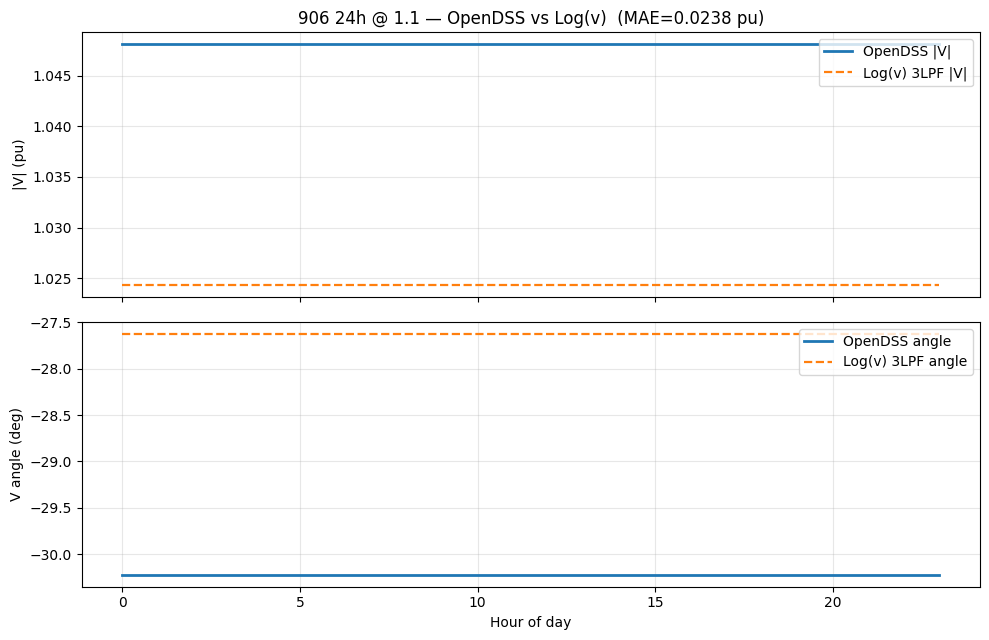

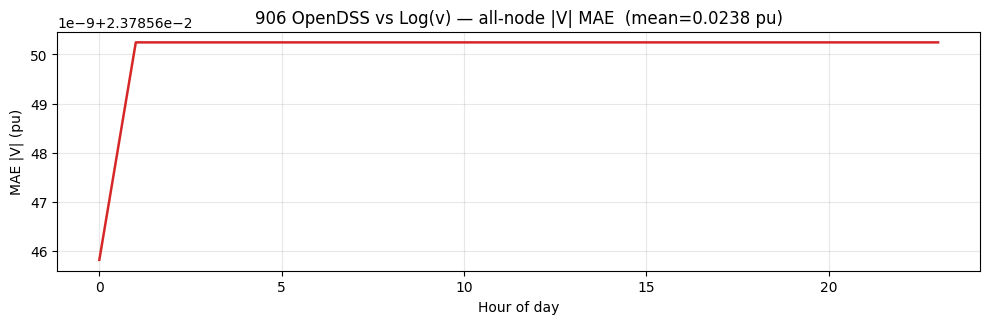

{'feeder': '906',
 'wall_s': 2.1169092999989516,
 'n_bad': 0,
 'mean_mae_vm': 0.02378565006157607}

In [17]:
%matplotlib inline
import os
import sys
from pathlib import Path

# ------------------------------------------------------------
# Daily OpenDSS vs Log(v) — change FEEDER only
# ------------------------------------------------------------
FEEDER = "906"             # options: "ieee34" | "906" | "8500"
SMOKE_TEST = True          # True: NPTS=24 (1 h steps). False: 288 × 5 min
DAY = 4                    # used by 8500 only (representative-days CSVs)
# Leave None to use feeder defaults (or override, e.g. ["l2841632.1"] for 8500)
PLOT_NODES = None
REG_COLS = None

def _find_repo() -> Path:
    env = os.environ.get("GNN2_REPO_ROOT", "").strip()
    cands = [Path(env)] if env else []
    cands += [
        Path(r"C:\Users\alita\OneDrive\Desktop\GNN2"),
        Path.cwd(),
        Path("/content/GNN2"),
    ]
    for raw in cands:
        root = Path(raw).expanduser().resolve()
        if (root / "logv3lpf_daily_opendss_compare.py").is_file():
            return root
    raise FileNotFoundError("Need GNN2 repo with logv3lpf_daily_opendss_compare.py")

REPO = _find_repo()
os.chdir(REPO)
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))
_pkg = str((REPO / "Log-v-3LPF").resolve())
if _pkg in sys.path:
    sys.path.remove(_pkg)
sys.path.insert(0, _pkg)

for mod in list(sys.modules):
    if mod.startswith("logv3lpf") or mod in (
        "logv3lpf_daily_opendss_compare",
        "logv3lpf_daily_demo",
    ):
        sys.modules.pop(mod, None)

from logv3lpf_daily_opendss_compare import run_daily_opendss_vs_logv3lpf

NPTS = 24 if SMOKE_TEST else 288
STEP_MIN = 60.0 if SMOKE_TEST else 5.0

series = run_daily_opendss_vs_logv3lpf(
    REPO,
    feeder=FEEDER,
    day=int(DAY),
    npts=int(NPTS),
    step_min=float(STEP_MIN),
    plot_nodes=PLOT_NODES,
    reg_cols=REG_COLS,
    show_plots=True,
    save_plots=False,  # True → also write PNGs under out_dir
    out_dir=REPO / "outputs" / "logv3lpf_daily_compare",
)
{
    "feeder": series.get("feeder"),
    "wall_s": series.get("wall_s"),
    "n_bad": series.get("n_bad"),
    "mean_mae_vm": float(__import__("numpy").nanmean(series["mae_vm_all_nodes"])),
}



## IEEE 34 (Mirzaei) — GNN dataset generation (chunked)

Generate chunked OpenDSS snapshot data for DA-GPS training on **Dr. Mirzaei's IEEE34_PV.dss** (`new dss from dr mirzaei/IEEE34_PV.dss`).

Same chunked driver pattern as the 906 / 8500 cells above. Generator script: `run_original_style_dataset_ieee34_mirzaei.py`.

### Full vs smoke sizes
| Mode | `TOTAL_SCENARIOS` | `N_SAMPLES_PER_SCENARIO` | `SCENARIOS_PER_CHUNK` | chunks |
|---|---|---|---|---|
| Full (`SMOKE_TEST=False`) | 2000 | 40 | 50 | 40 |
| Smoke (`SMOKE_TEST=True`) | 4 | 8 | 2 | 2 |

### Save location (`CHUNK_ROOT`)
- **Colab:** `/content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked`
- **Windows (preferred):** `K:\My Drive\datasets_gnn2\original_ieee34_mirzaei_chunked`
- Fallback: `D:\datasets\...` or `{repo}\datasets_gnn2\...`

### What this feeder has (vs 906 / 8500)
| | IEEE 8500 | 906 LVTestCase | **IEEE 34 Mirzaei** |
|---|---|---|---|
| DER | PV (+ optional BESS) | none | **PV850 + PV860** (PV850 has Volt-Var InvControl) |
| Load models | mostly const-P | const-P | **mixed ZIP**: DSS models 1 / 2 / 4 / 5 |
| Caps | CapControl banks | none | **fixed** C844 / C848 (no CapControl) |
| Regs | RegControl taps | none | native `rega*/regb*` transformers (**no RegControl**) |
| Profiles | 5-min load + irrad | 1-min load shapes | **5-min** `5minDayShape` + `IrradShape` (288 pts) |
| Trainer schema | real TARGET_* | dummy TARGET_* | **dummy TARGET_*** (same 8500 column names) + real IEEE34 meta for system tokens |

ZIP shares (`share_m*_p`) are **randomized per scenario** (`RANDOMIZE_ZIP_MODELS=True`) so those tokens are not constant; set False to keep the Mirzaei DSS default model mix.

### Per-chunk outputs (`run_***/`)
- `gnn_node_index_master.csv` (Laplacian PE)
- `gnn_edges_phase_static.csv`
- `gnn_sample_meta.csv` — dummy 8500 `TARGET_*` plus IEEE34 tokens (grid, PV post, ZIP shares, native taps, fixed cap kvar)
- `gnn_node_features_and_targets_mvagg.csv` ← what DA-GPS loads (compat copy; no split-phase agg)

### After generation
Point the IEEE34 DA-GPS training cell's `CHUNK_PARENT` at `CHUNK_ROOT` below.


In [22]:
# ============================================================
# CHUNKED RUN: scenarios x samples/scenario — IEEE 34 Mirzaei
# - runs in chunks, different seed / out folder per chunk
# - PE from static edges each chunk
# - *_mvagg.csv compat file (identity; no split-phase aggregation)
# - dummy 8500 TARGET_* cap/reg meta + real IEEE34 system-token columns
# ============================================================
import os
import math
import time
from pathlib import Path

# ---------------- user controls ----------------
SMOKE_TEST = False  # True = tiny path check; set False for full 2000×40

TOTAL_SCENARIOS = 2000
N_SAMPLES_PER_SCENARIO = 40
SCENARIOS_PER_CHUNK = 50
BASE_SEED = 3420230

SIGMA_LOAD = 0.02
SIGMA_PV = 0.02

# Scenario totals are scaled around injection BASELINE (~849 kW / 501 kvar / 975 kW PV)
P_LOAD_SCALE_RANGE = (0.95, 1.05)
Q_LOAD_SCALE_RANGE = (0.95, 1.05)
P_PV_SCALE_RANGE = (0.95, 1.05)

VMIN_SAFE_PU = 0.85
VMAX_SAFE_PU = 1.10

# OpenDSS ControlMode while sampling: "static" lets InvControl Volt-Var settle;
# "off" freezes controls. Prefer static so PV Q (autonomous) varies in the data.
CONTROL_MODE = "static"
# Per-scenario random Load.Model in {1,2,4,5} so ZIP-share tokens are informative.
RANDOMIZE_ZIP_MODELS = True

NODE_PE_K = 8
NODE_PE_SEED = 42
NODE_PE_ZERO_EIG_TOL = 1e-8

RETURN_NODE_DF = False
WRITE_MVAGG_COMPAT = True
DELETE_RAW_NODE_CSV_AFTER_MVAGG = True  # training only needs *_mvagg.csv

if SMOKE_TEST:
    TOTAL_SCENARIOS = 4
    N_SAMPLES_PER_SCENARIO = 8
    SCENARIOS_PER_CHUNK = 2
    print("SMOKE_TEST=True → TOTAL_SCENARIOS=4, N_SAMPLES_PER_SCENARIO=8, SCENARIOS_PER_CHUNK=2")

CANDIDATES = [
    r"C:\Users\alita\OneDrive\Desktop\GNN2",
    "/content/GNN-Sandia",
    "/content/GNN2",
    os.getcwd(),
]

_REPO = None
for root in CANDIDATES:
    if os.path.isdir(root) and os.path.isfile(os.path.join(root, "run_original_style_dataset_ieee34_mirzaei.py")):
        _REPO = os.path.abspath(root)
        break
if _REPO is None:
    raise FileNotFoundError("Could not locate repo root containing run_original_style_dataset_ieee34_mirzaei.py")

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

_K_GNN2 = Path(r"K:\My Drive\datasets_gnn2")
_K_MYDRIVE = Path(r"K:\My Drive")

if IN_COLAB:
    CHUNK_ROOT = Path("/content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked")
elif _K_GNN2.exists() or _K_MYDRIVE.exists():
    CHUNK_ROOT = _K_GNN2 / "original_ieee34_mirzaei_chunked"
elif Path(r"D:\datasets").exists():
    CHUNK_ROOT = Path(r"D:\datasets\original_ieee34_mirzaei_chunked")
else:
    CHUNK_ROOT = Path(_REPO) / "datasets_gnn2" / "original_ieee34_mirzaei_chunked"

CHUNK_ROOT.mkdir(parents=True, exist_ok=True)
print("CHUNK_ROOT:", CHUNK_ROOT)

script_path = os.path.join(_REPO, "run_original_style_dataset_ieee34_mirzaei.py")
os.chdir(_REPO)
print("CWD:", os.getcwd())
print("SCRIPT:", script_path)

ns = {"__name__": "run_original_style_dataset_ieee34_mirzaei", "__file__": script_path}
exec(open(script_path, encoding="utf-8").read(), ns)

dss_file = ns["DSS_FILE"]
print("DSS_FILE:", dss_file)
print("DSS exists:", Path(dss_file).is_file())
if not Path(dss_file).is_file():
    raise FileNotFoundError(f"Missing IEEE34 DSS: {dss_file}")

n_chunks = math.ceil(TOTAL_SCENARIOS / SCENARIOS_PER_CHUNK)
print(f"\nTotal chunks: {n_chunks} | SMOKE_TEST={SMOKE_TEST} | CONTROL_MODE={CONTROL_MODE}")

for chunk_idx in range(n_chunks):
    s0 = chunk_idx * SCENARIOS_PER_CHUNK
    n_this = min(SCENARIOS_PER_CHUNK, TOTAL_SCENARIOS - s0)
    chunk_seed = int(BASE_SEED + 100003 * (chunk_idx + 1))
    out_dir = CHUNK_ROOT / f"run_{chunk_idx+1:03d}_scen_{s0:04d}_{s0+n_this-1:04d}_seed_{chunk_seed}"
    out_dir.mkdir(parents=True, exist_ok=True)

    ns["OUT_DIR"] = out_dir
    ns["EDGE_CSV"] = out_dir / "gnn_edges_phase_static.csv"
    ns["NODE_CSV"] = out_dir / "gnn_node_features_and_targets.csv"
    ns["SAMPLE_CSV"] = out_dir / "gnn_sample_meta.csv"
    ns["NODE_INDEX_CSV"] = out_dir / "gnn_node_index_master.csv"
    ns["MVAGG_CSV"] = out_dir / "gnn_node_features_and_targets_mvagg.csv"

    print(f"\n=== Chunk {chunk_idx+1}/{n_chunks} ===")
    print(f"Scenarios in chunk: {n_this}")
    print(f"Seed: {chunk_seed}")
    print(f"OUT_DIR: {out_dir}")

    gen_kw = dict(
        n_scenarios=int(n_this),
        k_snapshots_per_scenario_total=int(N_SAMPLES_PER_SCENARIO),
        bins_by_profile={"load": 3, "pv": 3, "net": 3},
        include_anchors=True,
        master_seed=int(chunk_seed),
        sigma_load=float(SIGMA_LOAD),
        sigma_pv=float(SIGMA_PV),
        p_load_scale_range=tuple(P_LOAD_SCALE_RANGE),
        q_load_scale_range=tuple(Q_LOAD_SCALE_RANGE),
        p_pv_scale_range=tuple(P_PV_SCALE_RANGE),
        vmin_safe_pu=float(VMIN_SAFE_PU),
        vmax_safe_pu=float(VMAX_SAFE_PU),
        include_source_in_safe_band=False,
        return_node_df=bool(RETURN_NODE_DF),
        node_pe_k=int(NODE_PE_K),
        node_pe_seed=int(NODE_PE_SEED),
        node_pe_zero_eig_tol=float(NODE_PE_ZERO_EIG_TOL),
        write_mvagg_compat=bool(WRITE_MVAGG_COMPAT),
        delete_raw_node_csv_after_mvagg=bool(DELETE_RAW_NODE_CSV_AFTER_MVAGG),
        control_mode=str(CONTROL_MODE),
        randomize_zip_models=bool(RANDOMIZE_ZIP_MODELS),
    )

    t0 = time.time()
    df_sample, df_node = ns["generate_original_style_dataset_ieee34_mirzaei"](**gen_kw)

    dt = time.time() - t0
    n_kept = int(df_sample["sample_id"].nunique()) if len(df_sample) else 0
    print(f"Chunk done in {dt/60:.1f} min | kept samples: {n_kept} | rows sample_meta: {len(df_sample)}")
    print("Saved:")
    print(" -", ns["NODE_INDEX_CSV"])
    print(" -", ns["EDGE_CSV"])
    print(" -", ns["SAMPLE_CSV"])
    if not DELETE_RAW_NODE_CSV_AFTER_MVAGG:
        print(" -", ns["NODE_CSV"])
    print(" -", ns["MVAGG_CSV"])

print("\nAll chunks finished.")
print("Next: set IEEE34 DA-GPS CHUNK_PARENT to:", CHUNK_ROOT)


CHUNK_ROOT: K:\My Drive\datasets_gnn2\original_ieee34_mirzaei_chunked
CWD: C:\Users\alita\OneDrive\Desktop\GNN2
SCRIPT: C:\Users\alita\OneDrive\Desktop\GNN2\run_original_style_dataset_ieee34_mirzaei.py
DSS_FILE: C:\Users\alita\OneDrive\Desktop\GNN2\new dss from dr mirzaei\IEEE34_PV.dss
DSS exists: True

Total chunks: 40 | SMOKE_TEST=False | CONTROL_MODE=static

=== Chunk 1/40 ===
Scenarios in chunk: 50
Seed: 3520233
OUT_DIR: K:\My Drive\datasets_gnn2\original_ieee34_mirzaei_chunked\run_001_scen_0000_0049_seed_3520233
[DSS] maxcontroliter=20000
[ieee34] nodes_all=95 nodes_graph=89 control_mode=static
[saved] phase-edge CSV -> K:\My Drive\datasets_gnn2\original_ieee34_mirzaei_chunked\run_001_scen_0000_0049_seed_3520233\gnn_edges_phase_static.csv | rows=172 | cols=17 | bidirectional=True
[ieee34] computed PE k=8
[ieee34] scenario 1/50 done in 0.3s | samples so far=40
[ieee34] scenario 2/50 done in 0.3s | samples so far=80
[ieee34] scenario 3/50 done in 0.3s | samples so far=120
[ieee34] s

## DA-GPS training on IEEE 34 Mirzaei (chunked)

Train the existing multitask DA-GPS model on the **already-generated** IEEE34 chunked dataset. **Do not regenerate** for training — point at:

- Local: `K:\My Drive\datasets_gnn2\original_ieee34_mirzaei_chunked`
- Colab: `/content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked`

### System / latent tokens (chosen for IEEE 34)

`--n_system_tokens` allocates learnable **global tokens** after the fixed (dummy) cap-bank and regulator tokens. With `--aux_meta_cols`, column `i` supervises system-token slot `i` via normalized MSE (`--lambda_pv`).

For IEEE 34 we use **10 supervised system tokens** that match what actually varies on this feeder:

| # | Meta column | Why |
|---|-------------|-----|
| 1–2 | `P_grid_upstream_post_kw`, `Q_grid_upstream_post_kvar` | Substation / net operating point |
| 3–4 | `pv_pv850_p_post_kw`, `pv_pv850_q_post_kvar` | PV850 **active + Volt-Var Q** (autonomous InvControl) |
| 5–6 | `pv_pv860_p_post_kw`, `pv_pv860_q_post_kvar` | PV860 post-solve P/Q |
| 7–10 | `share_m1_p`, `share_m2_p`, `share_m4_p`, `share_m5_p` | ZIP / load-model mix (ConstP / ConstZ / CVR / ConstI), **randomized per scenario** |

**Not** used as supervised tokens (written to meta for diagnostics only):

- Native `reg_*_tap_pu` — mostly fixed (no RegControl on Mirzaei)
- Fixed `cap_c844_*` / `cap_c848_*` kvar
- Dummy 8500 `TARGET_*` cap/reg columns — required by trainer schema; keep `lambda_cap=0`, `lambda_reg=0`

### IEEE 34 vs 906 vs 8500 training

| Setting | 8500 (typical) | 906 | **IEEE 34 (this cell)** |
|--------|----------------|-----|-------------------------|
| Dataset | `original_8500_...` | `original_906_...` | `original_ieee34_mirzaei_chunked` |
| `n_system_tokens` | 10 | 2 | **10** |
| Meta aux | PV + losses | grid P/Q | **grid + 2×PV P/Q + 4 ZIP shares** |
| Cap / reg loss | `> 0` | **0** | **0** (dummy TARGET_*) |
| Physics | optional | off | **off** (`PHYSICS_WEIGHT=0`) |

Caches use **ieee34-specific** names so they never collide with 906/8500.


In [20]:
# --- DA-GPS training on IEEE 34 Mirzaei (long-running; Colab GPU or local CUDA) ---
import os
import sys
import re
import subprocess
import datetime
import warnings
from pathlib import Path

DRIVE_ROOT = Path("/content/drive")
MYDRIVE_DATA = DRIVE_ROOT / "MyDrive/datasets_gnn2"
COLAB_CHUNK_DEFAULT = MYDRIVE_DATA / "original_ieee34_mirzaei_chunked"
WIN_CHUNK_DEFAULT = Path(r"K:\My Drive\datasets_gnn2\original_ieee34_mirzaei_chunked")
WIN_RUNS_DEFAULT = Path(r"K:\My Drive\datasets_gnn2\runs")
WIN_CACHE_PARENT = Path(r"K:\My Drive\datasets_gnn2\cache")


def _is_windows_drive_path(path) -> bool:
    s = str(path).strip().replace("/", "\\")
    return len(s) >= 2 and s[1] == ":" and s[0].isalpha()


def _on_colab() -> bool:
    try:
        import google.colab  # noqa: F401
        return True
    except ImportError:
        return False


def _drive_mounted() -> bool:
    return DRIVE_ROOT.is_dir() and (DRIVE_ROOT / "MyDrive").is_dir()


def _resolve_data_path(path: Path, *, label: str, colab_fallback: Path | None = None) -> Path:
    """Resolve a data path; never join Windows drive letters with cwd on Linux."""
    raw = str(path)
    if _is_windows_drive_path(raw):
        if _on_colab() and colab_fallback is not None:
            warnings.warn(
                f"{label}={raw!r} is a Windows path on Linux/Colab; using {colab_fallback} instead.",
                UserWarning,
                stacklevel=2,
            )
            return colab_fallback.expanduser().resolve()
        if _on_colab():
            raise ValueError(
                f"{label}={raw!r} is a Windows absolute path and invalid on Colab. "
                f"Mount Drive and use e.g. {COLAB_CHUNK_DEFAULT}"
            )
        return Path(raw).expanduser().resolve()
    p = Path(path).expanduser()
    if p.is_absolute():
        return p.resolve()
    return (Path.cwd() / p).resolve()


def _find_node_pe_csv(chunk_parent: Path) -> Path:
    hits = sorted(chunk_parent.glob("run_*/gnn_node_index_master.csv"))
    if not hits:
        raise FileNotFoundError(
            f"No run_*/gnn_node_index_master.csv under {chunk_parent}"
        )
    return hits[0]


def _sorted_run_chunk_dirs(chunk_parent: Path) -> list[Path]:
    return sorted(
        (p for p in chunk_parent.iterdir() if p.is_dir() and p.name.startswith("run_")),
        key=lambda p: p.name,
    )


_FULL_CHUNK_MIN_SCEN = 50  # full: scen_0000_0049 => 50; smoke: scen_0000_0001 => 2


def _parse_run_scen_span(name: str) -> int | None:
    """Return (end - start + 1) from run_*_scen_{start}_{end}_seed_*, else None."""
    m = re.search(r"_scen_(\d+)_(\d+)(?:_|$)", name)
    if not m:
        return None
    start, end = int(m.group(1)), int(m.group(2))
    if end < start:
        return None
    return end - start + 1


def _classify_run_chunks(chunk_parent: Path, *, min_full_span: int = _FULL_CHUNK_MIN_SCEN):
    """Split run_* dirs into full vs other/smoke by scen span in the folder name."""
    all_runs = _sorted_run_chunk_dirs(chunk_parent)
    full, other = [], []
    for p in all_runs:
        span = _parse_run_scen_span(p.name)
        if span is not None and span >= min_full_span:
            full.append(p)
        else:
            other.append((p, span))
    return all_runs, full, other


def _select_training_chunk_glob(
    chunk_parent: Path,
    *,
    smoke: bool,
    smoke_count: int,
    min_full_span: int = _FULL_CHUNK_MIN_SCEN,
) -> str:
    """Build --chunk_subdir_glob with full vs smoke awareness.

    Full training (smoke=False): keep only folders whose scen span >= min_full_span
    (typically 50). Smoke folders (span=2) are skipped without deleting them.

    Smoke training (smoke=True): prefer the first `smoke_count` *full-size* chunks
    when available; otherwise fall back to the first `smoke_count` any run_*.
    """
    all_runs, full, other = _classify_run_chunks(chunk_parent, min_full_span=min_full_span)
    if not all_runs:
        raise FileNotFoundError(f"No run_* under {chunk_parent}")

    print(
        f"Chunk selection (SMOKE_TEST={smoke}, min_full_scen_span={min_full_span}): "
        f"{len(all_runs)} run_* found; {len(full)} full-size, {len(other)} other/smoke"
    )

    if smoke:
        pool = full if full else all_runs
        source = "full-size" if full else "any run_* (no full-size chunks found)"
        if len(pool) < smoke_count:
            raise ValueError(
                f"SMOKE_CHUNK_COUNT={smoke_count} but only {len(pool)} {source} "
                f"under {chunk_parent}"
            )
        kept = pool[:smoke_count]
        kept_names = {p.name for p in kept}
        print(f"  smoke: taking first {smoke_count} from {source}")
        for p in all_runs:
            span = _parse_run_scen_span(p.name)
            span_s = f"span={span}" if span is not None else "unparseable span"
            if p.name in kept_names:
                print(f"  KEEP  {p.name} ({span_s})")
            elif full and p not in full:
                print(f"  SKIP  {p.name} ({span_s}; smoke prefers full-size chunks)")
            else:
                print(f"  SKIP  {p.name} ({span_s}; beyond first {smoke_count})")
        return ",".join(p.name for p in kept)

    if not full:
        raise RuntimeError(
            f"SMOKE_TEST=False but no full-size chunks (scen span >= {min_full_span}) "
            f"under {chunk_parent}. Found {len(all_runs)} run_* folder(s)."
        )
    for p, span in other:
        span_s = f"span={span}" if span is not None else "unparseable span"
        print(
            f"  SKIP  {p.name} ({span_s}; need span>={min_full_span} for full training)"
        )
    for p in full:
        span = _parse_run_scen_span(p.name)
        print(f"  KEEP  {p.name} (span={span}; full)")
    return ",".join(p.name for p in full)


def _chunks_from_subdir_glob(chunk_parent: Path, glob_pat: str) -> list[Path]:
    import fnmatch

    glob_pat = str(glob_pat).strip()
    if "," in glob_pat:
        allowed = {s.strip() for s in glob_pat.split(",") if s.strip()}
        chunks = sorted(
            (p for p in chunk_parent.iterdir() if p.is_dir() and p.name in allowed),
            key=lambda p: p.name,
        )
        missing = allowed - {p.name for p in chunks}
        if missing:
            raise FileNotFoundError(f"Missing smoke chunk folders: {sorted(missing)}")
        return chunks
    return sorted(
        (p for p in chunk_parent.iterdir() if p.is_dir() and fnmatch.fnmatch(p.name, glob_pat)),
        key=lambda p: p.name,
    )


def _write_smoke_compare_manifest(
    runs_parent: Path,
    *,
    out_dir: Path,
    physics_weight: float,
    chunk_glob: str,
    n_chunks: int,
    epochs: int,
    seed: int,
) -> None:
    import json as _json

    path = runs_parent / "_smoke_compare_manifest_906.json"
    manifest = {}
    if path.is_file():
        manifest = _json.loads(path.read_text(encoding="utf-8"))
    key = "physics" if physics_weight > 0 else "baseline"
    manifest[key] = {
        "run_dir": str(out_dir.resolve()),
        "physics_weight": physics_weight,
        "chunk_glob": chunk_glob,
        "n_chunks": n_chunks,
        "epochs": epochs,
        "seed": seed,
        "feeder": "906_lvtestcase",
    }
    path.write_text(_json.dumps(manifest, indent=2), encoding="utf-8")
    print(f"Smoke compare manifest ({key}) -> {path}")


# Colab: mount Drive when chunks/caches live under MyDrive
if _on_colab() and not _drive_mounted():
    from google.colab import drive
    drive.mount("/content/drive")

# --- smoke / full-run toggles ---
SMOKE_TEST = True
SMOKE_CHUNK_COUNT = 3  # first N full-size run_* when available; 3-5 = fast multi-chunk
SMOKE_EPOCHS = 15
SMOKE_PATIENCE = 5
SMOKE_SEED = 42
_DA_CACHE_NAME = "da_gps_chunked_ieee34_smoke_gine" if SMOKE_TEST else "da_gps_chunked_ieee34_full_gine"
_GNN_CACHE_NAME = "gnn_only_chunked_ieee34_full_gine"

# --- paths: auto-detect Colab + Drive; prefer K: on Windows ---
_env_repo = os.environ.get("GNN2_REPO_ROOT", "").strip()
REPO = Path(_env_repo).expanduser().resolve() if _env_repo else Path.cwd().resolve()
if not (REPO / "train_da_gps_multitask_complex_voltage_gine.py").is_file():
    raise FileNotFoundError(f"Repo root missing trainer script: {REPO}")

if _on_colab():
    if not _drive_mounted():
        raise RuntimeError(
            "Colab requires Google Drive mounted. Re-run this cell and approve Drive access, "
            "or: from google.colab import drive; drive.mount('/content/drive')"
        )
    CHUNK_PARENT = COLAB_CHUNK_DEFAULT
    DA_CACHE_ROOT = MYDRIVE_DATA / f"cache/{_DA_CACHE_NAME}"
    GNN_CACHE_ROOT = MYDRIVE_DATA / f"cache/{_GNN_CACHE_NAME}"
    RUNS_PARENT = MYDRIVE_DATA / "runs"
elif os.name == "nt":
    CHUNK_PARENT = WIN_CHUNK_DEFAULT
    DA_CACHE_ROOT = WIN_CACHE_PARENT / _DA_CACHE_NAME
    GNN_CACHE_ROOT = WIN_CACHE_PARENT / _GNN_CACHE_NAME
    RUNS_PARENT = WIN_RUNS_DEFAULT
else:
    CHUNK_PARENT = REPO / "datasets_gnn2_from pc/original_ieee34_mirzaei_chunked"
    DA_CACHE_ROOT = REPO / f"datasets_gnn2_from pc/cache/{_DA_CACHE_NAME}"
    GNN_CACHE_ROOT = REPO / f"datasets_gnn2_from pc/cache/{_GNN_CACHE_NAME}"
    RUNS_PARENT = REPO / "datasets_gnn2_from pc/runs"

NODE_PE_CSV = None  # auto: first run_*/gnn_node_index_master.csv under CHUNK_PARENT

# Optional overrides (use POSIX paths on Colab, not K:\...):
# CHUNK_PARENT = Path("/content/drive/MyDrive/datasets_gnn2/original_ieee34_mirzaei_chunked")
# NODE_PE_CSV = CHUNK_PARENT / "run_001_scen_0000_0001_seed_90720233/gnn_node_index_master.csv"

# --- lighter architecture ---
LIGHTER_HIDDEN = 64
LIGHTER_LAYERS = 2
LIGHTER_HEADS = 2
LIGHTER_NODE_EMB_DIM = 2

PHYSICS_WEIGHT = 0.0  # always off for IEEE34 (no 8500 PF catalogs)

# Substation upstream P/Q only (no PV aux, no loss tokens)
META_AUX_COLS = (
    "P_grid_upstream_post_kw,Q_grid_upstream_post_kvar,"
    "pv_pv850_p_post_kw,pv_pv850_q_post_kvar,"
    "pv_pv860_p_post_kw,pv_pv860_q_post_kvar,"
    "share_m1_p,share_m2_p,share_m4_p,share_m5_p"
)
N_SYSTEM_TOKENS = 10
META_LOSS_SCALE = 0.001  # fix buggy stored P/Q loss units if those cols are ingested
LAMBDA_PV = 0.1  # weight for meta-aux MSE on the 10 system tokens
LAMBDA_CAP = 0.0
LAMBDA_REG = 0.0

NUM_WORKERS = 0 if os.name == "nt" else 4

os.chdir(REPO)
sys.path.insert(0, str(REPO))
os.environ["PYTHONUNBUFFERED"] = "1"
os.environ.setdefault("GNN2_REPO_ROOT", str(REPO))

_colab_fb = COLAB_CHUNK_DEFAULT if _on_colab() else None
chunk_parent = _resolve_data_path(CHUNK_PARENT, label="CHUNK_PARENT", colab_fallback=_colab_fb)
if SMOKE_TEST:
    EPOCHS = SMOKE_EPOCHS
    PATIENCE = SMOKE_PATIENCE
else:
    EPOCHS = 200
    PATIENCE = 30
# Full: only scen-span >= 50 folders. Smoke: prefer first N full-size, else any run_*.
CHUNK_GLOB = _select_training_chunk_glob(
    chunk_parent, smoke=SMOKE_TEST, smoke_count=SMOKE_CHUNK_COUNT
)
da_cache_root = _resolve_data_path(
    DA_CACHE_ROOT,
    label="DA_CACHE_ROOT",
    colab_fallback=MYDRIVE_DATA / f"cache/{_DA_CACHE_NAME}" if _on_colab() else None,
)
gnn_cache_root = _resolve_data_path(
    GNN_CACHE_ROOT,
    label="GNN_CACHE_ROOT",
    colab_fallback=MYDRIVE_DATA / f"cache/{_GNN_CACHE_NAME}" if _on_colab() else None,
)
runs_parent = _resolve_data_path(
    RUNS_PARENT,
    label="RUNS_PARENT",
    colab_fallback=MYDRIVE_DATA / "runs" if _on_colab() else None,
)

print("=== Preflight (IEEE34 DA-GPS) ===")
print(f"REPO:           {REPO}")
print(f"SMOKE_TEST:     {SMOKE_TEST}")
print(f"SMOKE_CHUNK_COUNT: {SMOKE_CHUNK_COUNT}")
print(f"CHUNK_GLOB:     {CHUNK_GLOB}")
print(f"EPOCHS:         {EPOCHS}")
print(f"PATIENCE:       {PATIENCE}")
print(f"CHUNK_PARENT:   {chunk_parent}")
print(f"META_AUX_COLS:  {META_AUX_COLS}")
print(f"N_SYSTEM_TOKENS:{N_SYSTEM_TOKENS}")
print(f"META_LOSS_SCALE:{META_LOSS_SCALE}")
print(f"lambda_cap/reg/pv: {LAMBDA_CAP}/{LAMBDA_REG}/{LAMBDA_PV}")
print(f"PHYSICS_WEIGHT: {PHYSICS_WEIGHT}")
if not chunk_parent.is_dir():
    raise FileNotFoundError(f"CHUNK_PARENT not found: {chunk_parent}")

run_preview = sorted(
    p.name for p in chunk_parent.iterdir() if p.is_dir() and p.name.startswith("run_")
)[:5]
print(f"run_* preview:  {run_preview}")

if NODE_PE_CSV is None:
    node_pe = _find_node_pe_csv(chunk_parent)
else:
    node_pe = _resolve_data_path(NODE_PE_CSV, label="NODE_PE_CSV", colab_fallback=None)
    if not node_pe.is_file():
        warnings.warn(
            f"NODE_PE_CSV not found at {node_pe}; auto-discovering under CHUNK_PARENT.",
            UserWarning,
            stacklevel=2,
        )
        node_pe = _find_node_pe_csv(chunk_parent)

print(f"NODE_PE_CSV:    {node_pe}")
print(f"DA_CACHE_ROOT:  {da_cache_root}")
print(f"GNN_CACHE_ROOT: {gnn_cache_root}")
print(f"RUNS_PARENT:    {runs_parent}")
print("PF_DATA_ROOT:   (skipped — PHYSICS_WEIGHT=0)")
print("=================")

da_cache_root.mkdir(parents=True, exist_ok=True)
gnn_cache_root.mkdir(parents=True, exist_ok=True)
runs_parent.mkdir(parents=True, exist_ok=True)

chunks = _chunks_from_subdir_glob(chunk_parent, CHUNK_GLOB)
if not chunks:
    raise RuntimeError(f"No folders for CHUNK_GLOB={CHUNK_GLOB!r} under {chunk_parent}")

for p in chunks:
    for name in (
        "gnn_node_features_and_targets_mvagg.csv",
        "gnn_edges_phase_static.csv",
        "gnn_sample_meta.csv",
    ):
        if not (p / name).is_file():
            raise FileNotFoundError(f"Missing {name} in {p.name}")

print(f"Found {len(chunks)} chunk(s) for CHUNK_GLOB under {chunk_parent}")

tag = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
out_dir = runs_parent / (
    f"da_gps_ieee34_l{LIGHTER_LAYERS}_h{LIGHTER_HIDDEN}_gine_gridPQ"
    f"{'_smoke' if SMOKE_TEST else ''}_{tag}"
)
out_dir.mkdir(parents=True, exist_ok=True)

_early_stop = "total"

cmd = [
    sys.executable, "-u", "train_da_gps_multitask_complex_voltage_gine.py",
    "--chunk_parent", str(chunk_parent),
    "--chunk_subdir_glob", CHUNK_GLOB,
    "--nodes_csv", "gnn_node_features_and_targets_mvagg.csv",
    "--edge_catalog_csv", "gnn_edges_phase_static.csv",
    "--meta_csv", "gnn_sample_meta.csv",
    "--node_feature_cols", "p_load_kw,q_load_kvar,p_pv_kw",
    "--exclude_bess_features",
    "--node_pe_csv", str(node_pe),
    "--node_pe_cols", "auto",
    "--n_system_tokens", str(N_SYSTEM_TOKENS),
    "--aux_meta_cols", META_AUX_COLS,
    "--meta_loss_scale", str(META_LOSS_SCALE),
    "--lambda_pv", str(LAMBDA_PV),
    "--out_dir", str(out_dir),
    "--cache_dir", str(da_cache_root),
    "--bootstrap_gnn_cache_dir", str(gnn_cache_root),
    "--epochs", str(EPOCHS),
    "--batch_size", "64",
    "--hidden", str(LIGHTER_HIDDEN),
    "--layers", str(LIGHTER_LAYERS),
    "--heads", str(LIGHTER_HEADS),
    "--node_emb_dim", str(LIGHTER_NODE_EMB_DIM),
    "--edge_emb_dim", "0",
    "--lr", "5e-4",
    "--weight_decay", "1e-5",
    "--lambda_cap", str(LAMBDA_CAP),
    "--lambda_reg", str(LAMBDA_REG),
    "--reg_loss", "mse",
    "--patience", str(PATIENCE),
    "--seed", str(SMOKE_SEED),
    "--train_frac", "0.80",
    "--val_frac", "0.10",
    "--sample_frac", "1.0",
    "--num_workers", str(NUM_WORKERS),
    "--log_every", "10",
    "--checkpoint_every", "10",
    "--early_stop_on", _early_stop,
    "--dropout", "0.1",
]

# PHYSICS_WEIGHT must stay 0 for IEEE34 — no PF flags added.

print(f"PHYSICS_WEIGHT={PHYSICS_WEIGHT} (baseline; no 8500 physics)")
print(f"early_stop_on={_early_stop}")
print("\nRunning:\n ", " ".join(cmd), "\n", flush=True)

with subprocess.Popen(
    cmd,
    cwd=str(REPO),
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    bufsize=1,
    text=True,
) as proc:
    assert proc.stdout is not None
    for line in proc.stdout:
        print(line, end="")
    rc = proc.wait()

if rc != 0:
    raise subprocess.CalledProcessError(rc, cmd)

print("\nTraining completed.")
print("Run dir:", out_dir.resolve())
print("Checkpoint (best):", (out_dir / "da_gps_multitask_best.pt").resolve())
print("Checkpoint (last):", (out_dir / "training_last.pt").resolve())
print("Report:", (out_dir / "da_gps_report.json").resolve())
_write_smoke_compare_manifest(
    runs_parent,
    out_dir=out_dir,
    physics_weight=PHYSICS_WEIGHT,
    chunk_glob=CHUNK_GLOB,
    n_chunks=len(chunks),
    epochs=EPOCHS,
    seed=SMOKE_SEED if SMOKE_TEST else 42,
)


FileNotFoundError: Repo root missing trainer script: C:\Users\alita\OneDrive\Desktop\GNN2\906 bus system\OpenDSS-master\OpenDSS-master\Distrib\IEEETestCases\LVTestCase